# ORFD fine-tuning: U-Net, DeepLabV3+, SegFormer-B0, and ROD

This notebook fine-tunes four **RUGD-trained** binary segmentation models on ORFD:

- U-Net
- DeepLabV3+
- SegFormer-B0
- ROD (EfficientSAM-S encoder + ROD segmentation decoder)

Experiment:

**RUGD-pretrained checkpoint → ORFD fine-tuning → ORFD test**

The first four models retain the original direct `512 × 512` resize pipeline.

ROD retains its architecture-specific preprocessing:
- aspect-ratio-preserving resize and padding to `512 × 512`;
- ImageNet-equivalent ROD normalization in 0–255 pixel scale;
- EfficientSAM internal input size `1024 × 1024`;
- frozen EfficientSAM encoder, matching the RUGD ROD training configuration.

All final results are written directly to:

`/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd`

**Training loss:** all four ORFD fine-tuning runs use only `CrossEntropyLoss(ignore_index=255)`. Dice/F1 remains an evaluation metric only.

## 1. Install dependencies and mount Google Drive

In [1]:
!pip -q install segmentation-models-pytorch timm pandas matplotlib tqdm

import os
import sys

ROD_REPO = "/content/offroad_roadseg"

if not os.path.exists(ROD_REPO):
    !git clone --depth 1 https://github.com/ict-ans-617/offroad_roadseg.git {ROD_REPO}

if ROD_REPO not in sys.path:
    sys.path.insert(0, ROD_REPO)

print("ROD repository:", ROD_REPO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.1 MB/s eta 0:00:00
Cloning into '/content/offroad_roadseg'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 80 (delta 17), reused 78 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (80/80), 4.32 MiB | 3.15 MiB/s, done.
Resolving deltas: 100% (17/17), done.
ROD repository: /content/offroad_roadseg


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Configuration

In [5]:
from pathlib import Path

# --------------------------------------------------
# Dataset archives
# --------------------------------------------------
ORFD_ZIPS = {
    "training": Path(
        "/content/drive/MyDrive/IRP/01_data/raw/ORFD/training.zip"
    ),
    "validation": Path(
        "/content/drive/MyDrive/IRP/01_data/raw/ORFD/validation.zip"
    ),
    "testing": Path(
        "/content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip"
    ),
}

# --------------------------------------------------
# RUGD-trained checkpoints
# --------------------------------------------------
CHECKPOINTS = {
    "U-Net": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "unet_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "DeepLabV3+": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth"
    ),
    "SegFormer-B0": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "segformer_b0_rugd_binary_ground_best_20epochs.pth"
    ),
    "ROD": Path(
        "/content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/"
        "rod_rugd_binary_ground_best_20epochs.pth"
    ),
}

# --------------------------------------------------
# Local data + direct Google Drive output
# --------------------------------------------------
LOCAL_DATA_ROOT = Path("/content/ORFD_RGB")

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd"
)

# Optional zero-shot ORFD result from the cross-dataset experiment.
ZERO_SHOT_CSV_CANDIDATES = [
    Path(
        "/content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/"
        "rugd_checkpoints_on_orfd_summary.csv"
    ),
]

# --------------------------------------------------
# Task configuration
# --------------------------------------------------
NON_TRAVERSABLE_CLASS = 0
TRAVERSABLE_CLASS = 1
IGNORE_INDEX = 255
NUM_CLASSES = 2

INPUT_SIZE = (512, 512)

BATCH_SIZE = 8
ROD_BATCH_SIZE = 1

NUM_WORKERS = 2
PIN_MEMORY = True

EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42

# Use small integer limits for a quick pipeline test.
# Restore all three to None before the formal experiment.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

MODEL_CONFIGS = {
    "U-Net": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "preprocess_mode": "direct_resize",
    },
    "DeepLabV3+": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "resnet34",
        "encoder_output_stride": 16,
        "preprocess_mode": "direct_resize",
    },
    "SegFormer-B0": {
        "input_size": INPUT_SIZE,
        "normalization": "imagenet",
        "encoder_name": "mit_b0",
        "preprocess_mode": "direct_resize",
    },
    "ROD": {
        "input_size": INPUT_SIZE,
        "normalization": "rod_imagenet_255",
        "encoder_name": "EfficientSAM-S",
        "preprocess_mode": "aspect_ratio_pad",
        "encoder_input_size": (1024, 1024),
        "freeze_encoder": True,
    },
}

MODEL_DISPLAY_ORDER = [
    "U-Net",
    "DeepLabV3+",
    "SegFormer-B0",
    "ROD",
]

print("Dataset archives:")
for split, path in ORFD_ZIPS.items():
    print(f"  {split}: {path}")

print("\nCheckpoints:")
for model_name, path in CHECKPOINTS.items():
    print(f"  {model_name}: {path}")

print("\nResults:")
print(RESULTS_ROOT)

Dataset archives:
  training: /content/drive/MyDrive/IRP/01_data/raw/ORFD/training.zip
  validation: /content/drive/MyDrive/IRP/01_data/raw/ORFD/validation.zip
  testing: /content/drive/MyDrive/IRP/01_data/raw/ORFD/testing.zip

Checkpoints:
  U-Net: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/unet_resnet34_rugd_binary_ground_best_20epochs.pth
  DeepLabV3+: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/deeplabv3plus_resnet34_rugd_binary_ground_best_20epochs.pth
  SegFormer-B0: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/segformer_b0_rugd_binary_ground_best_20epochs.pth
  ROD: /content/drive/MyDrive/IRP/02_in_domain_rugd/checkpoints/rod_rugd_binary_ground_best_20epochs.pth

Results:
/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd


### Quick pipeline test

Before formal training, temporarily use:

```python
EPOCHS = 1
MAX_TRAIN_SAMPLES = 50
MAX_VAL_SAMPLES = 20
MAX_TEST_SAMPLES = 20
```

After the complete notebook runs successfully, restore:

```python
EPOCHS = 20
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None
```

## 3. Imports, reproducibility, and path validation

In [6]:
import os
import re
import json
import time
import random
import shutil
import zipfile
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import segmentation_models_pytorch as smp


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "WARNING: GPU is not enabled. In Colab select "
        "Runtime > Change runtime type > GPU."
    )

for split, archive_path in ORFD_ZIPS.items():
    if not archive_path.exists():
        raise FileNotFoundError(
            f"{split} archive not found: {archive_path}"
        )

for model_name, checkpoint_path in CHECKPOINTS.items():
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"{model_name} checkpoint not found: {checkpoint_path}"
        )

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 4. Extract and validate ORFD

In [7]:
def split_has_sequences(directory: Path) -> bool:
    if not directory.exists():
        return False

    return any(
        path.is_dir()
        and (path / "image_data").exists()
        and (path / "gt_image").exists()
        for path in directory.iterdir()
    )


def extract_split(split_name: str, archive_path: Path) -> Path:
    final_split_dir = LOCAL_DATA_ROOT / split_name

    if split_has_sequences(final_split_dir):
        print(
            f"{split_name}: already extracted -> "
            f"{final_split_dir}"
        )
        return final_split_dir

    temporary_dir = (
        LOCAL_DATA_ROOT / f"_{split_name}_extracting"
    )

    if temporary_dir.exists():
        shutil.rmtree(temporary_dir)

    temporary_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(f"Extracting {archive_path.name} ...")

    with zipfile.ZipFile(
        archive_path,
        "r",
    ) as archive:
        archive.extractall(temporary_dir)

    candidate_roots = [
        temporary_dir / split_name,
        temporary_dir,
    ]

    source_root = None

    for candidate in candidate_roots:
        if split_has_sequences(candidate):
            source_root = candidate
            break

    if source_root is None:
        nested_candidates = [
            path
            for path in temporary_dir.rglob(split_name)
            if path.is_dir()
            and split_has_sequences(path)
        ]

        if len(nested_candidates) == 1:
            source_root = nested_candidates[0]

    if source_root is None:
        preview = [
            str(path.relative_to(temporary_dir))
            for path in list(
                temporary_dir.rglob("*")
            )[:40]
        ]

        raise RuntimeError(
            f"Could not find ORFD sequences after extracting "
            f"{archive_path}. First entries: {preview}"
        )

    if final_split_dir.exists():
        shutil.rmtree(final_split_dir)

    if source_root == temporary_dir:
        temporary_dir.rename(final_split_dir)
    else:
        shutil.move(
            str(source_root),
            str(final_split_dir),
        )

        if temporary_dir.exists():
            shutil.rmtree(temporary_dir)

    print(
        f"{split_name}: ready -> "
        f"{final_split_dir}"
    )

    return final_split_dir


SPLIT_ROOTS = {
    split: extract_split(split, archive_path)
    for split, archive_path in ORFD_ZIPS.items()
}

for split, root in SPLIT_ROOTS.items():
    sequence_count = sum(
        1
        for path in root.iterdir()
        if path.is_dir()
        and (path / "image_data").exists()
        and (path / "gt_image").exists()
    )

    print(
        f"{split}: {sequence_count} valid sequence folders"
    )

Extracting training.zip ...
training: ready -> /content/ORFD_RGB/training
Extracting validation.zip ...
validation: ready -> /content/ORFD_RGB/validation
Extracting testing.zip ...
testing: ready -> /content/ORFD_RGB/testing
training: 21 valid sequence folders
validation: 3 valid sequence folders
testing: 6 valid sequence folders


## 5. Match images and masks

In [8]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}


def list_images(root: Path):
    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def canonical_stem(path: Path) -> str:
    stem = path.stem.lower()

    suffix_patterns = [
        r"_fillcolor$",
        r"_label_color$",
        r"_label$",
        r"_mask$",
        r"_gt$",
        r"_rgb$",
        r"_image$",
    ]

    changed = True

    while changed:
        changed = False

        for pattern in suffix_patterns:
            updated = re.sub(
                pattern,
                "",
                stem,
            )

            if updated != stem:
                stem = updated
                changed = True

    return stem


def build_split_manifest(
    split_name: str,
    split_root: Path,
):
    rows = []
    reports = []

    sequence_dirs = sorted(
        path
        for path in split_root.iterdir()
        if path.is_dir()
    )

    for sequence_dir in tqdm(
        sequence_dirs,
        desc=f"Indexing {split_name}",
    ):
        image_root = (
            sequence_dir / "image_data"
        )
        mask_root = (
            sequence_dir / "gt_image"
        )

        if (
            not image_root.exists()
            or not mask_root.exists()
        ):
            reports.append({
                "split": split_name,
                "sequence": sequence_dir.name,
                "status": (
                    "missing image_data or gt_image"
                ),
                "images": 0,
                "masks": 0,
                "pairs": 0,
            })
            continue

        image_paths = list_images(image_root)
        mask_paths = list_images(mask_root)

        image_index = defaultdict(list)
        mask_index = defaultdict(list)

        for image_path in image_paths:
            image_index[
                canonical_stem(image_path)
            ].append(image_path)

        for mask_path in mask_paths:
            mask_index[
                canonical_stem(mask_path)
            ].append(mask_path)

        common_keys = sorted(
            set(image_index)
            & set(mask_index)
        )

        duplicate_keys = []

        for key in common_keys:
            if (
                len(image_index[key]) != 1
                or len(mask_index[key]) != 1
            ):
                duplicate_keys.append(key)
                continue

            rows.append({
                "split": split_name,
                "sequence": sequence_dir.name,
                "stem": key,
                "image_path": str(
                    image_index[key][0]
                ),
                "mask_path": str(
                    mask_index[key][0]
                ),
            })

        reports.append({
            "split": split_name,
            "sequence": sequence_dir.name,
            "status": (
                "ok"
                if not duplicate_keys
                else "duplicate keys skipped"
            ),
            "images": len(image_paths),
            "masks": len(mask_paths),
            "pairs": (
                len(common_keys)
                - len(duplicate_keys)
            ),
            "unmatched_images": len(
                set(image_index)
                - set(mask_index)
            ),
            "unmatched_masks": len(
                set(mask_index)
                - set(image_index)
            ),
            "duplicate_keys": len(
                duplicate_keys
            ),
        })

    return (
        pd.DataFrame(rows),
        pd.DataFrame(reports),
    )


manifests = {}
reports = {}

for split_name, split_root in SPLIT_ROOTS.items():
    manifests[split_name], reports[split_name] = (
        build_split_manifest(
            split_name,
            split_root,
        )
    )

manifest_df = pd.concat(
    manifests.values(),
    ignore_index=True,
)

pairing_report_df = pd.concat(
    reports.values(),
    ignore_index=True,
)

manifest_df.to_csv(
    RESULTS_ROOT / "orfd_manifest.csv",
    index=False,
)

pairing_report_df.to_csv(
    RESULTS_ROOT / "orfd_pairing_report.csv",
    index=False,
)

display(
    manifest_df.groupby("split")
    .size()
    .rename("paired_samples")
    .to_frame()
)

problem_sequences = pairing_report_df[
    (pairing_report_df["status"] != "ok")
    | (
        pairing_report_df[
            "unmatched_images"
        ].fillna(0) > 0
    )
    | (
        pairing_report_df[
            "unmatched_masks"
        ].fillna(0) > 0
    )
]

print(
    "Sequences with pairing warnings:",
    len(problem_sequences),
)

display(problem_sequences.head(20))

Indexing training:   0%|          | 0/21 [00:00<?, ?it/s]

Indexing validation:   0%|          | 0/3 [00:00<?, ?it/s]

Indexing testing:   0%|          | 0/6 [00:00<?, ?it/s]

,paired_samples
split,
testing,2555
training,8398
validation,1245


Sequences with pairing warnings: 0


,split,sequence,status,images,masks,pairs,unmatched_images,unmatched_masks,duplicate_keys


In [9]:
train_df = manifests[
    "training"
].reset_index(drop=True)

val_df = manifests[
    "validation"
].reset_index(drop=True)

test_df = manifests[
    "testing"
].reset_index(drop=True)

if MAX_TRAIN_SAMPLES is not None:
    train_df = train_df.iloc[
        :MAX_TRAIN_SAMPLES
    ].copy()

if MAX_VAL_SAMPLES is not None:
    val_df = val_df.iloc[
        :MAX_VAL_SAMPLES
    ].copy()

if MAX_TEST_SAMPLES is not None:
    test_df = test_df.iloc[
        :MAX_TEST_SAMPLES
    ].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

assert len(train_df) > 0
assert len(val_df) > 0
assert len(test_df) > 0

Training samples: 8398
Validation samples: 1245
Testing samples: 2555


## 6. ORFD mask conversion and sanity checks

In [10]:
def load_orfd_raw_mask(mask_path):
    raw = np.array(
        Image.open(mask_path).convert("L"),
        dtype=np.uint8,
    )

    if raw.ndim != 2:
        raise ValueError(
            f"Expected a 2D ORFD mask, "
            f"got shape={raw.shape}: {mask_path}"
        )

    values = set(
        np.unique(raw).tolist()
    )

    if not values.issubset(
        {0, 128, 255}
    ):
        raise ValueError(
            f"Unexpected ORFD values in "
            f"{mask_path}: {sorted(values)}"
        )

    return raw

def load_orfd_binary_mask(mask_path):
    """
    Convert ORFD fill-color grayscale mask to binary classes.

    Raw ORFD values:
        0   = non-traversable
        128 = unreachable
        255 = traversable

    Model classes:
        0   = non-traversable
        1   = traversable
        255 = ignore
    """
    raw = load_orfd_raw_mask(mask_path)

    binary = np.full(
        raw.shape,
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    # Raw 0 = non-traversable
    binary[raw == 0] = NON_TRAVERSABLE_CLASS

    # Raw 128 = unreachable
    binary[raw == 128] = IGNORE_INDEX

    # Raw 255 = traversable
    binary[raw == 255] = TRAVERSABLE_CLASS

    return binary


sample_paths = train_df[
    "mask_path"
].sample(
    n=min(20, len(train_df)),
    random_state=RANDOM_SEED,
).tolist()

observed_values = set()

for mask_path in sample_paths:
    raw = load_orfd_raw_mask(
        mask_path
    )

    binary = load_orfd_binary_mask(
        mask_path
    )

    observed_values.update(
        np.unique(raw).tolist()
    )

    print(
        Path(mask_path).name,
        "| raw:",
        np.unique(raw),
        "| binary:",
        np.unique(binary),
    )

print(
    "All observed raw values:",
    sorted(observed_values),
)



1620331025158_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1623734160875_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1619778704754_fillcolor.png | raw: [  0 255] | binary: [0 1]
1623171122154_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1623688549205_fillcolor.png | raw: [  0 255] | binary: [0 1]
1624045556961_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620497363412_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620373626182_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1619778759579_fillcolor.png | raw: [  0 255] | binary: [0 1]
1623733088543_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1619778713658_fillcolor.png | raw: [  0 255] | binary: [0 1]
1623170274384_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1620330618119_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1623171132996_fillcolor.png | raw: [  0 128 255] | binary: [  0   1 255]
1623697217352_fillcolor.pn

## 7. Dataset and DataLoaders

In [11]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

ROD_PIXEL_MEAN = np.array(
    [123.675, 116.28, 103.53],
    dtype=np.float32,
)

ROD_PIXEL_STD = np.array(
    [58.395, 57.12, 57.375],
    dtype=np.float32,
)


class ORFDBinaryDataset(Dataset):
    # Direct-resize pipeline for U-Net, DeepLabV3+, SegFormer-B0.
    def __init__(
        self,
        dataframe,
        input_size=INPUT_SIZE,
        training=False,
    ):
        self.df = dataframe.reset_index(
            drop=True
        )
        self.input_size = tuple(
            input_size
        )
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        mask = Image.fromarray(
            load_orfd_binary_mask(
                row["mask_path"]
            )
        )

        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.3:
                image = TF.adjust_brightness(
                    image,
                    random.uniform(0.85, 1.15),
                )
                image = TF.adjust_contrast(
                    image,
                    random.uniform(0.85, 1.15),
                )

        image = TF.resize(
            image,
            self.input_size,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        mask = TF.resize(
            mask,
            self.input_size,
            interpolation=InterpolationMode.NEAREST,
        )

        image = TF.to_tensor(image)

        image = TF.normalize(
            image,
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

        mask = torch.from_numpy(
            np.array(
                mask,
                dtype=np.uint8,
            )
        ).long()

        return {
            "image": image,
            "mask": mask,
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "sequence": row["sequence"],
            "stem": row["stem"],
        }


def rod_resize_pad_pair(
    image_np,
    mask_np,
    size=512,
):
    h, w = image_np.shape[:2]

    scale = size / max(h, w)

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    image_resized = np.array(
        Image.fromarray(image_np).resize(
            (new_w, new_h),
            resample=Image.Resampling.BILINEAR,
        )
    )

    mask_resized = np.array(
        Image.fromarray(mask_np).resize(
            (new_w, new_h),
            resample=Image.Resampling.NEAREST,
        ),
        dtype=np.uint8,
    )

    image_canvas = np.zeros(
        (size, size, 3),
        dtype=np.uint8,
    )

    mask_canvas = np.full(
        (size, size),
        IGNORE_INDEX,
        dtype=np.uint8,
    )

    top = (size - new_h) // 2
    left = (size - new_w) // 2

    image_canvas[
        top:top + new_h,
        left:left + new_w,
    ] = image_resized

    mask_canvas[
        top:top + new_h,
        left:left + new_w,
    ] = mask_resized

    return image_canvas, mask_canvas


class ORFDRODDataset(Dataset):
    # ROD-specific aspect-ratio-preserving resize + padding.
    def __init__(
        self,
        dataframe,
        training=False,
    ):
        self.df = dataframe.reset_index(
            drop=True
        )
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        mask = Image.fromarray(
            load_orfd_binary_mask(
                row["mask_path"]
            )
        )

        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.3:
                image = TF.adjust_brightness(
                    image,
                    random.uniform(0.85, 1.15),
                )
                image = TF.adjust_contrast(
                    image,
                    random.uniform(0.85, 1.15),
                )

        image_np = np.array(
            image,
            dtype=np.uint8,
        )

        mask_np = np.array(
            mask,
            dtype=np.uint8,
        )

        image_np, mask_np = (
            rod_resize_pad_pair(
                image_np,
                mask_np,
                size=INPUT_SIZE[0],
            )
        )

        image_np = (
            image_np.astype(np.float32)
            - ROD_PIXEL_MEAN
        ) / ROD_PIXEL_STD

        image_tensor = (
            torch.from_numpy(image_np)
            .permute(2, 0, 1)
            .contiguous()
        )

        mask_tensor = (
            torch.from_numpy(mask_np)
            .long()
        )

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "sequence": row["sequence"],
            "stem": row["stem"],
        }


# Baseline datasets/loaders.
train_dataset = ORFDBinaryDataset(
    train_df,
    training=True,
)
val_dataset = ORFDBinaryDataset(
    val_df,
    training=False,
)
test_dataset = ORFDBinaryDataset(
    test_df,
    training=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

# ROD datasets/loaders.
rod_train_dataset = ORFDRODDataset(
    train_df,
    training=True,
)
rod_val_dataset = ORFDRODDataset(
    val_df,
    training=False,
)
rod_test_dataset = ORFDRODDataset(
    test_df,
    training=False,
)

rod_train_loader = DataLoader(
    rod_train_dataset,
    batch_size=ROD_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
rod_val_loader = DataLoader(
    rod_val_dataset,
    batch_size=ROD_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
rod_test_loader = DataLoader(
    rod_test_dataset,
    batch_size=ROD_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)


def get_model_data(model_name):
    if model_name == "ROD":
        return (
            rod_train_dataset,
            rod_val_dataset,
            rod_test_dataset,
            rod_train_loader,
            rod_val_loader,
            rod_test_loader,
        )

    return (
        train_dataset,
        val_dataset,
        test_dataset,
        train_loader,
        val_loader,
        test_loader,
    )


sample_batch = next(
    iter(train_loader)
)

rod_sample_batch = next(
    iter(rod_train_loader)
)

print("Baseline batch:", sample_batch["image"].shape)
print("ROD batch:", rod_sample_batch["image"].shape)
print("ROD mask values:", torch.unique(rod_sample_batch["mask"]))

Baseline batch: torch.Size([8, 3, 512, 512])
ROD batch: torch.Size([1, 3, 512, 512])
ROD mask values: tensor([  0,   1, 255])


In [12]:
def denormalize(
    image_tensor,
    model_name="U-Net",
):
    image = image_tensor.detach().cpu()

    if model_name == "ROD":
        image = image.permute(
            1, 2, 0
        ).numpy()

        image = (
            image * ROD_PIXEL_STD
            + ROD_PIXEL_MEAN
        )

        return np.clip(
            image / 255.0,
            0,
            1,
        )

    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = image * std + mean

    return (
        image.clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

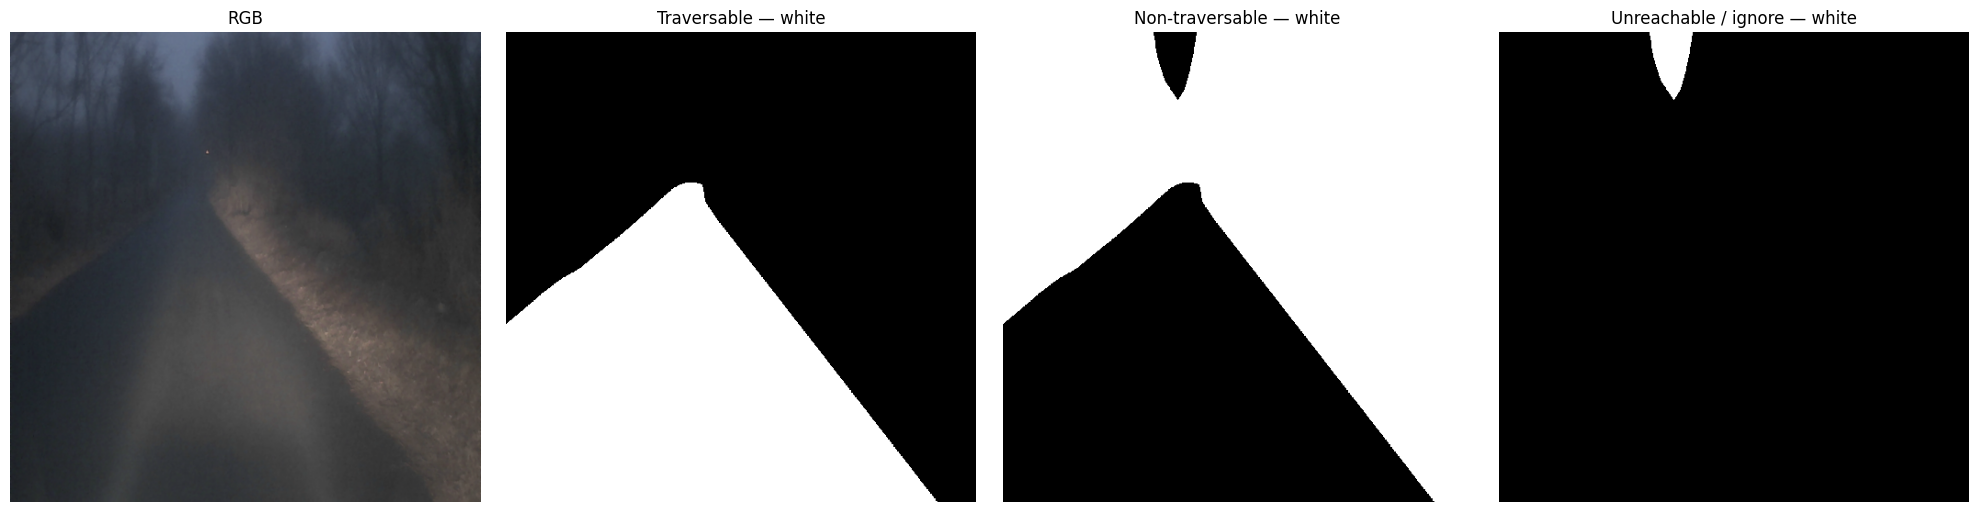

In [13]:
sample = train_dataset[0]

figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5),
)

rgb = denormalize(sample["image"])
mask = sample["mask"].numpy()

axes[0].imshow(rgb)
axes[0].set_title("RGB")

axes[1].imshow(
    mask == TRAVERSABLE_CLASS,
    cmap="gray",
)
axes[1].set_title("Traversable — white")

axes[2].imshow(
    mask == NON_TRAVERSABLE_CLASS,
    cmap="gray",
)
axes[2].set_title("Non-traversable — white")

axes[3].imshow(
    mask == IGNORE_INDEX,
    cmap="gray",
)
axes[3].set_title("Unreachable / ignore — white")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 8. Model definitions and robust checkpoint loading

In [14]:
import os
import shutil
import zipfile

# --------------------------------------------------
# ROD / EfficientSAM setup
# --------------------------------------------------
WEIGHTS_DIR = (
    Path(ROD_REPO)
    / "efficient_sam"
    / "weights"
)

WEIGHTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WEIGHTS_ZIP = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt.zip"
)

VITS_PATH = (
    WEIGHTS_DIR
    / "efficient_sam_vits.pt"
)

if not VITS_PATH.exists():
    if not WEIGHTS_ZIP.exists():
        !wget -q --show-progress https://github.com/yformer/EfficientSAM/raw/main/weights/efficient_sam_vits.pt.zip -O {WEIGHTS_ZIP}

    with zipfile.ZipFile(
        WEIGHTS_ZIP,
        "r",
    ) as archive:
        archive.extractall(
            WEIGHTS_DIR
        )

from efficient_sam.build_efficient_sam import (
    build_efficient_sam_vits,
)
from seg_decoder import SegHead


def load_rod_encoder(
    checkpoint_path,
):
    checkpoint_path = Path(
        checkpoint_path
    ).resolve()

    efficient_sam_dir = (
        Path(ROD_REPO)
        / "efficient_sam"
    )

    expected_checkpoint = (
        efficient_sam_dir
        / "weights"
        / "efficient_sam_vits.pt"
    ).resolve()

    if checkpoint_path != expected_checkpoint:
        expected_checkpoint.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        shutil.copy2(
            checkpoint_path,
            expected_checkpoint,
        )

    previous_cwd = Path.cwd()

    try:
        os.chdir(
            efficient_sam_dir
        )

        efficient_sam_model = (
            build_efficient_sam_vits()
        )

    finally:
        os.chdir(
            previous_cwd
        )

    return (
        efficient_sam_model.image_encoder
    )


class ROD(nn.Module):
    def __init__(
        self,
        checkpoint_path,
        freeze=True,
    ):
        super().__init__()

        self.encoder = load_rod_encoder(
            checkpoint_path
        )

        self.decoder = SegHead()

        self.freeze = freeze

        self.encoder_input_size = int(
            self.encoder.img_size
        )

        if self.freeze:
            for parameter in (
                self.encoder.parameters()
            ):
                parameter.requires_grad = False

            self.encoder.eval()

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        if self.freeze:
            self.encoder.eval()

        return self

    def forward(
        self,
        x,
    ):
        output_size = x.shape[-2:]

        if x.shape[-2:] != (
            self.encoder_input_size,
            self.encoder_input_size,
        ):
            encoder_x = F.interpolate(
                x,
                size=(
                    self.encoder_input_size,
                    self.encoder_input_size,
                ),
                mode="bilinear",
                align_corners=False,
            )
        else:
            encoder_x = x

        if self.freeze:
            with torch.no_grad():
                features = self.encoder(
                    encoder_x.float()
                )
        else:
            features = self.encoder(
                encoder_x.float()
            )

        if torch.is_tensor(
            features
        ):
            features = features.float()

        elif isinstance(
            features,
            (list, tuple),
        ):
            features = [
                value.float()
                if torch.is_tensor(value)
                else value
                for value in features
            ]

        elif isinstance(
            features,
            dict,
        ):
            features = {
                key: (
                    value.float()
                    if torch.is_tensor(value)
                    else value
                )
                for key, value
                in features.items()
            }

        with torch.backends.cudnn.flags(
            enabled=False
        ):
            logits = self.decoder(
                features
            )

        if logits.shape[-2:] != (
            output_size
        ):
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )

        return logits


def build_model(
    model_name,
    checkpoint=None,
):
    config = MODEL_CONFIGS[
        model_name
    ]

    if model_name == "U-Net":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config["encoder_name"]
        )

        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "DeepLabV3+":
        encoder_name = (
            checkpoint.get(
                "encoder_name",
                config["encoder_name"],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config["encoder_name"]
        )

        output_stride = (
            checkpoint.get(
                "encoder_output_stride",
                config[
                    "encoder_output_stride"
                ],
            )
            if isinstance(
                checkpoint,
                dict,
            )
            else config[
                "encoder_output_stride"
            ]
        )

        return smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=None,
            encoder_output_stride=output_stride,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "SegFormer-B0":
        return smp.Segformer(
            encoder_name=config[
                "encoder_name"
            ],
            encoder_weights=None,
            in_channels=3,
            classes=NUM_CLASSES,
            activation=None,
        )

    if model_name == "ROD":
        return ROD(
            checkpoint_path=VITS_PATH,
            freeze=MODEL_CONFIGS[
                "ROD"
            ]["freeze_encoder"],
        )

    raise KeyError(
        f"Unknown model: {model_name}"
    )


def extract_state_dict(checkpoint):
    if isinstance(
        checkpoint,
        OrderedDict,
    ):
        return checkpoint

    if not isinstance(
        checkpoint,
        dict,
    ):
        raise TypeError(
            f"Unsupported checkpoint type: "
            f"{type(checkpoint)}"
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "net",
        "network",
    ]

    for key in candidate_keys:
        value = checkpoint.get(key)

        if isinstance(
            value,
            (dict, OrderedDict),
        ):
            return value

    tensor_values = sum(
        isinstance(
            value,
            torch.Tensor,
        )
        for value in checkpoint.values()
    )

    if tensor_values > 0:
        return checkpoint

    raise KeyError(
        "No model state dictionary found."
    )


def strip_prefixes(state_dict):
    cleaned = OrderedDict()

    prefixes = (
        "module.",
        "model.",
        "net.",
        "_orig_mod.",
    )

    for key, value in state_dict.items():
        new_key = key
        changed = True

        while changed:
            changed = False

            for prefix in prefixes:
                if new_key.startswith(
                    prefix
                ):
                    new_key = new_key[
                        len(prefix):
                    ]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def load_checkpoint_file(
    checkpoint_path,
):
    return torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )


def load_checkpoint_into_model(
    model,
    checkpoint,
    strict=True,
):
    state_dict = strip_prefixes(
        extract_state_dict(
            checkpoint
        )
    )

    model.load_state_dict(
        state_dict,
        strict=strict,
    )

    return model


for model_name, checkpoint_path in (
    CHECKPOINTS.items()
):
    print(
        "\n" + "=" * 80
    )
    print(model_name)
    print("=" * 80)

    checkpoint = load_checkpoint_file(
        checkpoint_path
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    load_checkpoint_into_model(
        model,
        checkpoint,
        strict=True,
    )

    print(
        "Checkpoint loaded successfully."
    )

/content/offroad_ro 100%[===================>]  93.75M   550MB/s    in 0.2s    

U-Net
Checkpoint loaded successfully.

DeepLabV3+
Checkpoint loaded successfully.

SegFormer-B0
Checkpoint loaded successfully.

ROD
Checkpoint loaded successfully.


## 9. Loss and metrics

In [15]:
def update_confusion_matrix(
    confusion_matrix,
    predictions,
    targets,
    num_classes=2,
    ignore_index=255,
):
    predictions = predictions.reshape(
        -1
    )

    targets = targets.reshape(
        -1
    )

    valid = (
        targets != ignore_index
    )

    predictions = predictions[
        valid
    ]

    targets = targets[
        valid
    ]

    valid_classes = (
        (targets >= 0)
        & (targets < num_classes)
        & (predictions >= 0)
        & (predictions < num_classes)
    )

    predictions = predictions[
        valid_classes
    ]

    targets = targets[
        valid_classes
    ]

    encoded = (
        targets * num_classes
        + predictions
    )

    bins = torch.bincount(
        encoded,
        minlength=num_classes ** 2,
    )

    confusion_matrix += bins.reshape(
        num_classes,
        num_classes,
    ).cpu()

    return confusion_matrix


def safe_divide(
    numerator,
    denominator,
):
    if denominator == 0:
        return float("nan")

    return float(
        numerator / denominator
    )


def metrics_from_confusion_matrix(
    cm,
):
    cm = cm.to(
        torch.float64
    )

    true_positive = torch.diag(cm)

    false_positive = (
        cm.sum(dim=0)
        - true_positive
    )

    false_negative = (
        cm.sum(dim=1)
        - true_positive
    )

    iou = torch.where(
        true_positive
        + false_positive
        + false_negative
        > 0,
        true_positive
        / (
            true_positive
            + false_positive
            + false_negative
        ),
        torch.nan,
    )

    dice = torch.where(
        2 * true_positive
        + false_positive
        + false_negative
        > 0,
        2 * true_positive
        / (
            2 * true_positive
            + false_positive
            + false_negative
        ),
        torch.nan,
    )

    precision = torch.where(
        true_positive
        + false_positive
        > 0,
        true_positive
        / (
            true_positive
            + false_positive
        ),
        torch.nan,
    )

    recall = torch.where(
        true_positive
        + false_negative
        > 0,
        true_positive
        / (
            true_positive
            + false_negative
        ),
        torch.nan,
    )

    accuracy = safe_divide(
        true_positive.sum().item(),
        cm.sum().item(),
    )

    return {
        "non_traversable_iou": (
            iou[0].item()
        ),
        "traversable_iou": (
            iou[1].item()
        ),
        "miou": (
            torch.nanmean(iou).item()
        ),
        "non_traversable_f1": (
            dice[0].item()
        ),
        "traversable_f1": (
            dice[1].item()
        ),
        "mean_f1": (
            torch.nanmean(dice).item()
        ),
        "non_traversable_precision": (
            precision[0].item()
        ),
        "traversable_precision": (
            precision[1].item()
        ),
        "mean_precision": (
            torch.nanmean(
                precision
            ).item()
        ),
        "non_traversable_recall": (
            recall[0].item()
        ),
        "traversable_recall": (
            recall[1].item()
        ),
        "mean_recall": (
            torch.nanmean(
                recall
            ).item()
        ),
        "accuracy": accuracy,
        "valid_pixels": int(
            cm.sum().item()
        ),
    }


def extract_logits(
    output,
    target_size,
):
    if isinstance(
        output,
        dict,
    ):
        if "out" in output:
            output = output["out"]
        elif "logits" in output:
            output = output[
                "logits"
            ]

    if hasattr(
        output,
        "logits",
    ):
        output = output.logits

    if output.shape[-2:] != tuple(
        target_size
    ):
        output = F.interpolate(
            output,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

    return output

## 10. Evaluation functions

In [16]:
@torch.inference_mode()
def evaluate(
    model,
    loader,
    device,
    model_name="model",
    measure_time=False,
):
    model.eval()

    confusion_matrix = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES,
        ),
        dtype=torch.int64,
    )

    total_loss = 0.0
    number_of_images = 0
    inference_times = []

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    if (
        measure_time
        and device.type == "cuda"
    ):
        warmup_batch = next(
            iter(loader)
        )

        warmup_images = (
            warmup_batch["image"][:1]
            .to(
                device,
                non_blocking=True,
            )
        )

        for _ in range(5):
            _ = model(
                warmup_images
            )

        torch.cuda.synchronize()

    for batch in tqdm(
        loader,
        desc=f"Evaluating {model_name}",
        leave=False,
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        if (
            measure_time
            and device.type == "cuda"
        ):
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        outputs = model(images)

        logits = extract_logits(
            outputs,
            target_size=(
                masks.shape[-2:]
            ),
        )

        if (
            measure_time
            and device.type == "cuda"
        ):
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        loss = criterion(
            logits,
            masks,
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        update_confusion_matrix(
            confusion_matrix,
            predictions.cpu(),
            masks.cpu(),
            NUM_CLASSES,
            IGNORE_INDEX,
        )

        if measure_time:
            per_image_ms = (
                elapsed
                / images.size(0)
                * 1000.0
            )

            inference_times.extend(
                [per_image_ms]
                * images.size(0)
            )

        number_of_images += (
            images.size(0)
        )

    result = metrics_from_confusion_matrix(
        confusion_matrix
    )

    result["loss"] = (
        total_loss
        / max(
            number_of_images,
            1,
        )
    )

    result["num_images"] = (
        number_of_images
    )

    if (
        measure_time
        and inference_times
    ):
        result[
            "mean_inference_time_ms"
        ] = float(
            np.mean(
                inference_times
            )
        )

        result["fps"] = (
            1000.0
            / result[
                "mean_inference_time_ms"
            ]
        )

    else:
        result[
            "mean_inference_time_ms"
        ] = np.nan

        result["fps"] = np.nan

    return (
        result,
        confusion_matrix,
    )


@torch.inference_mode()
def evaluate_per_image(
    model,
    loader,
    device,
    model_name,
):
    model.eval()
    rows = []

    for batch in tqdm(
        loader,
        desc=f"Per-image {model_name}",
        leave=False,
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        outputs = model(images)

        logits = extract_logits(
            outputs,
            target_size=(
                masks.shape[-2:]
            ),
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        for index in range(
            images.size(0)
        ):
            image_cm = torch.zeros(
                (
                    NUM_CLASSES,
                    NUM_CLASSES,
                ),
                dtype=torch.int64,
            )

            update_confusion_matrix(
                image_cm,
                predictions[
                    index
                ].cpu(),
                masks[
                    index
                ].cpu(),
                NUM_CLASSES,
                IGNORE_INDEX,
            )

            image_metrics = (
                metrics_from_confusion_matrix(
                    image_cm
                )
            )

            image_metrics.update({
                "model": model_name,
                "sequence": (
                    batch[
                        "sequence"
                    ][index]
                ),
                "stem": (
                    batch[
                        "stem"
                    ][index]
                ),
                "image_path": (
                    batch[
                        "image_path"
                    ][index]
                ),
                "mask_path": (
                    batch[
                        "mask_path"
                    ][index]
                ),
            })

            rows.append(
                image_metrics
            )

    return pd.DataFrame(rows)

## 11. Fine-tune one model

In [17]:
def save_training_curves(
    history_df,
    model_output_dir,
    model_name,
):
    history_df.to_csv(
        model_output_dir
        / "training_history.csv",
        index=False,
    )

    curve_metrics = [
        "train_loss",
        "val_loss",
        "val_miou",
        "val_traversable_iou",
        "val_non_traversable_iou",
    ]

    for metric in curve_metrics:
        if metric not in (
            history_df.columns
        ):
            continue

        plt.figure(
            figsize=(7, 4)
        )

        plt.plot(
            history_df["epoch"],
            history_df[metric],
            marker="o",
        )

        plt.xlabel("Epoch")
        plt.ylabel(metric)

        plt.title(
            f"{model_name}: {metric}"
        )

        plt.grid(True)
        plt.tight_layout()

        plt.savefig(
            model_output_dir
            / f"{metric}.png",
            dpi=150,
        )

        plt.show()


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device,
    criterion,
):
    model.train()

    total_loss = 0.0
    number_of_images = 0

    for batch in tqdm(
        loader,
        desc="Training",
        leave=False,
    ):
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(
                device.type == "cuda"
            ),
        ):
            outputs = model(images)

            logits = extract_logits(
                outputs,
                target_size=(
                    masks.shape[-2:]
                ),
            )

            loss = criterion(
                logits,
                masks,
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        total_loss += (
            loss.item()
            * images.size(0)
        )

        number_of_images += (
            images.size(0)
        )

    return (
        total_loss
        / max(
            number_of_images,
            1,
        )
    )


def model_safe_name(
    model_name,
):
    return (
        model_name.lower()
        .replace(
            "+",
            "plus",
        )
        .replace(
            "-",
            "_",
        )
        .replace(
            " ",
            "_",
        )
    )


def finetune_model(
    model_name,
    checkpoint_path,
    device,
):
    print(
        "\n" + "=" * 100
    )

    print(
        f"Fine-tuning {model_name}"
    )

    print("=" * 100)

    model_output_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    model_output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = (
        load_checkpoint_file(
            checkpoint_path
        )
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    model = load_checkpoint_into_model(
        model,
        checkpoint,
        strict=True,
    )

    model = model.to(device)

    (
        current_train_dataset,
        current_val_dataset,
        current_test_dataset,
        current_train_loader,
        current_val_loader,
        current_test_loader,
    ) = get_model_data(model_name)

    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2,
        )
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(
            device.type == "cuda"
        ),
    )

    best_validation_miou = -1.0
    best_epoch = -1
    patience_counter = 0
    history = []

    best_checkpoint_path = (
        model_output_dir
        / "best_orfd_finetuned.pth"
    )

    baseline_validation, _ = evaluate(
        model,
        current_val_loader,
        device,
        model_name=(
            f"{model_name} "
            "baseline validation"
        ),
    )

    print(
        "Baseline ORFD validation mIoU "
        "before fine-tuning:",
        baseline_validation["miou"],
    )

    for epoch in range(
        1,
        EPOCHS + 1,
    ):
        print(
            f"\nEpoch {epoch}/{EPOCHS}"
        )

        train_loss = train_one_epoch(
            model,
            current_train_loader,
            optimizer,
            scaler,
            device,
            criterion,
        )

        validation_metrics, _ = evaluate(
            model,
            current_val_loader,
            device,
            model_name=(
                f"{model_name} validation"
            ),
        )

        scheduler.step(
            validation_metrics["miou"]
        )

        current_learning_rate = (
            optimizer.param_groups[
                0
            ]["lr"]
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": (
                validation_metrics[
                    "loss"
                ]
            ),
            "val_non_traversable_iou": (
                validation_metrics[
                    "non_traversable_iou"
                ]
            ),
            "val_traversable_iou": (
                validation_metrics[
                    "traversable_iou"
                ]
            ),
            "val_miou": (
                validation_metrics[
                    "miou"
                ]
            ),
            "val_mean_f1": (
                validation_metrics[
                    "mean_f1"
                ]
            ),
            "val_accuracy": (
                validation_metrics[
                    "accuracy"
                ]
            ),
            "lr": current_learning_rate,
        }

        history.append(row)

        print(
            pd.DataFrame(
                [row]
            ).to_string(
                index=False
            )
        )

        if (
            validation_metrics["miou"]
            > best_validation_miou
        ):
            best_validation_miou = (
                validation_metrics[
                    "miou"
                ]
            )

            best_epoch = epoch
            patience_counter = 0

            torch.save(
                {
                    "model_name": model_name,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "source_checkpoint": str(
                        checkpoint_path
                    ),
                    "source_training_dataset": (
                        "RUGD"
                    ),
                    "target_training_dataset": (
                        "ORFD"
                    ),
                    "epoch": epoch,
                    "best_val_miou": (
                        best_validation_miou
                    ),
                    "encoder_name": (
                        MODEL_CONFIGS[
                            model_name
                        ]["encoder_name"]
                    ),
                    "encoder_output_stride": (
                        MODEL_CONFIGS[
                            model_name
                        ].get(
                            "encoder_output_stride"
                        )
                    ),
                    "input_size": INPUT_SIZE,
                    "ignore_index": (
                        IGNORE_INDEX
                    ),
                    "label_mapping": {
                        "0": (
                            "non_traversable"
                        ),
                        "1": (
                            "traversable"
                        ),
                        "255": "ignore",
                    },
                },
                best_checkpoint_path,
            )

            print(
                "Saved best checkpoint:",
                best_checkpoint_path,
            )

        else:
            patience_counter += 1

            print(
                "No validation improvement. "
                f"Patience: "
                f"{patience_counter}/"
                f"{EARLY_STOPPING_PATIENCE}"
            )

            if (
                patience_counter
                >= EARLY_STOPPING_PATIENCE
            ):
                print(
                    "Early stopping."
                )
                break

    history_df = pd.DataFrame(
        history
    )

    save_training_curves(
        history_df,
        model_output_dir,
        model_name,
    )

    best_checkpoint = (
        load_checkpoint_file(
            best_checkpoint_path
        )
    )

    model = build_model(
        model_name,
        checkpoint=best_checkpoint,
    )

    model = load_checkpoint_into_model(
        model,
        best_checkpoint,
        strict=True,
    )

    model = model.to(
        device
    )

    test_metrics, test_cm = evaluate(
        model,
        current_test_loader,
        device,
        model_name=(
            f"{model_name} ORFD test"
        ),
        measure_time=True,
    )

    per_image_df = evaluate_per_image(
        model,
        current_test_loader,
        device,
        model_name,
    )

    per_image_path = (
        model_output_dir
        / "orfd_test_per_image_metrics.csv"
    )

    per_image_df.to_csv(
        per_image_path,
        index=False,
    )

    np.save(
        model_output_dir
        / "test_confusion_matrix.npy",
        test_cm.numpy(),
    )

    result = {
        "model": model_name,
        "source_training_dataset": (
            "RUGD"
        ),
        "target_training_dataset": (
            "ORFD"
        ),
        "target_test_dataset": (
            "ORFD"
        ),
        "source_checkpoint": str(
            checkpoint_path
        ),
        "best_checkpoint": str(
            best_checkpoint_path
        ),
        "best_epoch": best_epoch,
        "best_val_miou": (
            best_validation_miou
        ),
        "baseline_val_miou": (
            baseline_validation[
                "miou"
            ]
        ),
        "num_train_images": len(
            current_train_dataset
        ),
        "num_val_images": len(
            current_val_dataset
        ),
        "num_test_images": len(
            current_test_dataset
        ),
        **{
            key: value
            for key, value
            in test_metrics.items()
            if key != "num_images"
        },
    }

    result_path = (
        model_output_dir
        / "test_summary.json"
    )

    with open(
        result_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            result,
            file,
            indent=2,
        )

    print(
        "\nFinal ORFD test result:"
    )

    display(
        pd.DataFrame(
            [result]
        ).T
    )

    return result

## 12. Run ORFD fine-tuning for all four models


Fine-tuning U-Net


Evaluating U-Net baseline validation:   0%|          | 0/156 [00:00<?, ?it/s]

Baseline ORFD validation mIoU before fine-tuning: 0.7219100978718158

Epoch 1/20


Training:   0%|          | 0/1050 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

...

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     6    0.013732  0.359237                 0.911292             0.801313  0.856302     0.921643      0.934666 0.00005
No validation improvement. Patience: 4/5

Epoch 7/20


Training:   0%|          | 0/1050 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Evaluating U-Net validation:   0%|          | 0/156 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     7    0.012961  0.308185                 0.915878             0.813525  0.864702     0.926634      0.938462 0.00005
No validation improvement. Patience: 5/5
Early stopping.


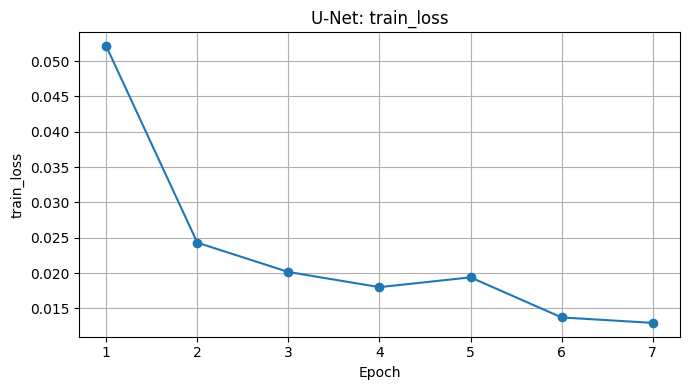

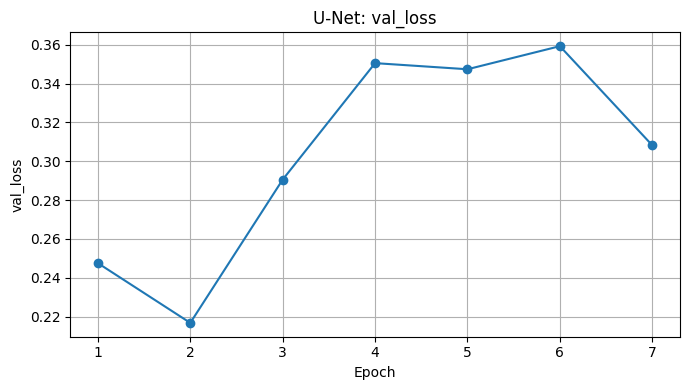

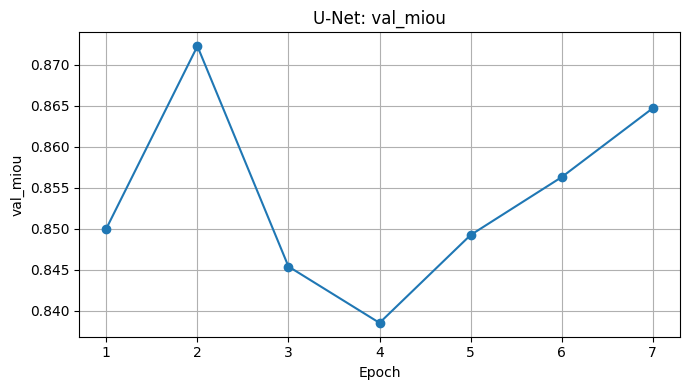

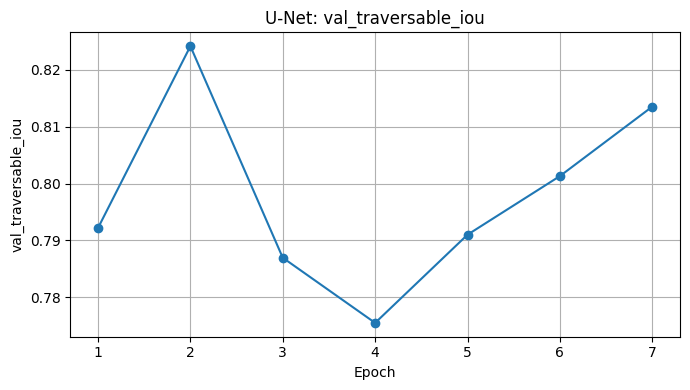

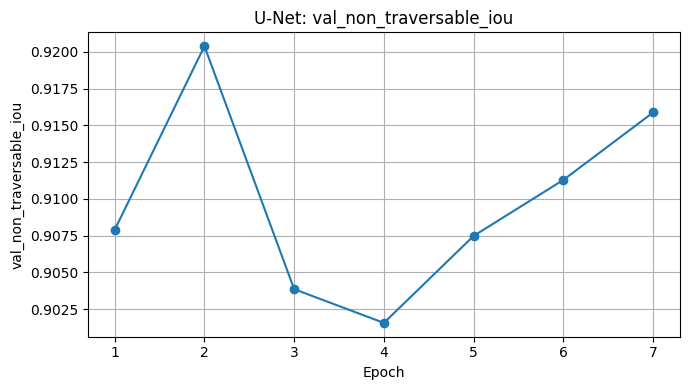

Evaluating U-Net ORFD test:   0%|          | 0/320 [00:00<?, ?it/s]

Per-image U-Net:   0%|          | 0/320 [00:00<?, ?it/s]


Final ORFD test result:


,0
model,U-Net
source_training_dataset,RUGD
target_training_dataset,ORFD
target_test_dataset,ORFD
source_checkpoint,/content/drive/MyDrive/IRP/02_in_domain_rugd/c...
best_checkpoint,/content/drive/MyDrive/IRP/04_target_domain_fi...
best_epoch,2
best_val_miou,0.872272
baseline_val_miou,0.72191
num_train_images,8398



Fine-tuning DeepLabV3+


...

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     5    0.015122  0.290156                 0.916166             0.813097  0.864632     0.926582       0.93857 0.00005
No validation improvement. Patience: 4/5

Epoch 6/20


Training:   0%|          | 0/1050 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Evaluating DeepLabV3+ validation:   0%|          | 0/156 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     6    0.014046  0.276065                 0.913916             0.809105  0.861511     0.924752      0.936929 0.00005
No validation improvement. Patience: 5/5
Early stopping.


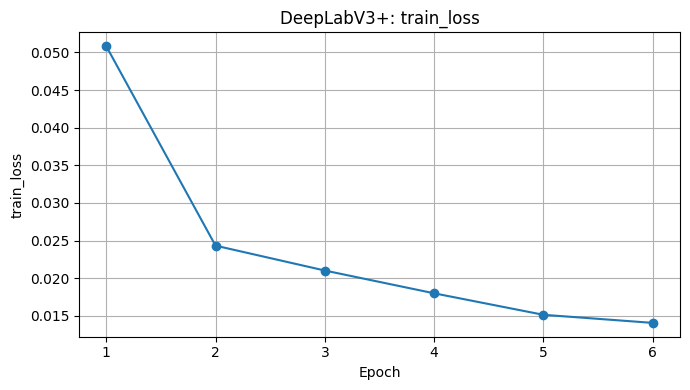

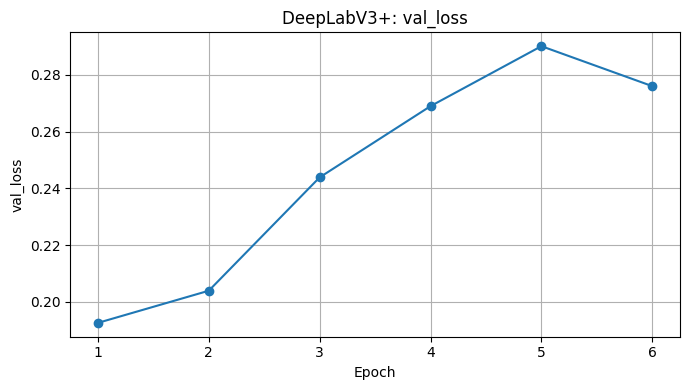

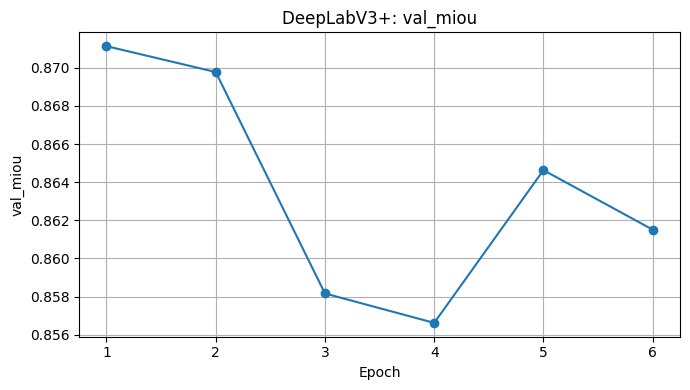

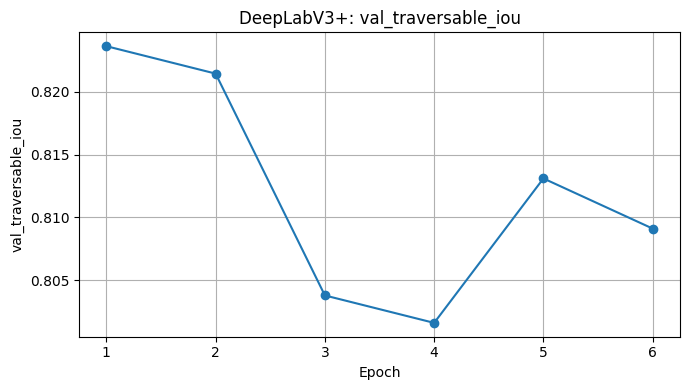

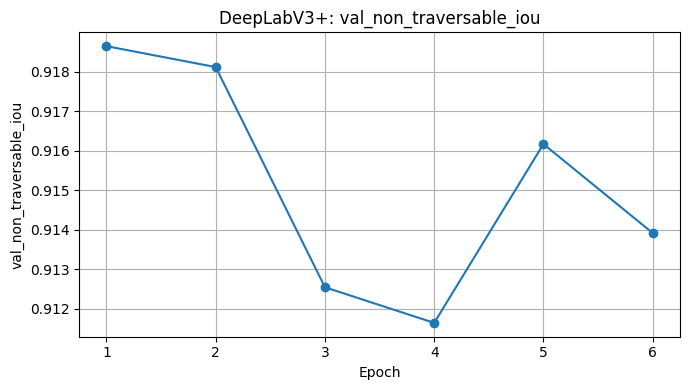

Evaluating DeepLabV3+ ORFD test:   0%|          | 0/320 [00:00<?, ?it/s]

Per-image DeepLabV3+:   0%|          | 0/320 [00:00<?, ?it/s]


Final ORFD test result:


,0
model,DeepLabV3+
source_training_dataset,RUGD
target_training_dataset,ORFD
target_test_dataset,ORFD
source_checkpoint,/content/drive/MyDrive/IRP/02_in_domain_rugd/c...
best_checkpoint,/content/drive/MyDrive/IRP/04_target_domain_fi...
best_epoch,1
best_val_miou,0.871134
baseline_val_miou,0.64073
num_train_images,8398



Fine-tuning SegFormer-B0


...

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy       lr
    10    0.014934   0.22668                   0.9303             0.849605  0.889952      0.94129      0.949991 0.000025
No validation improvement. Patience: 4/5

Epoch 11/20


Training:   0%|          | 0/1050 [00:00<?, ?it/s]

Evaluating SegFormer-B0 validation:   0%|          | 0/156 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy       lr
    11    0.014466  0.239489                 0.926349             0.841302  0.883826     0.937789      0.947031 0.000025
No validation improvement. Patience: 5/5
Early stopping.


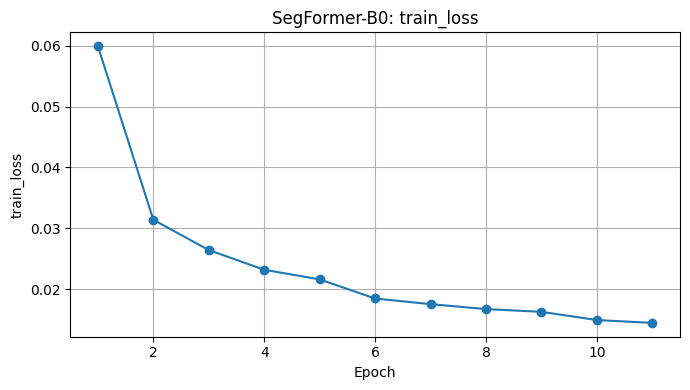

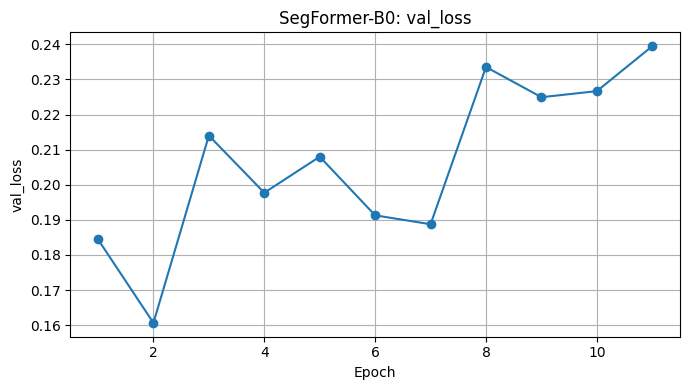

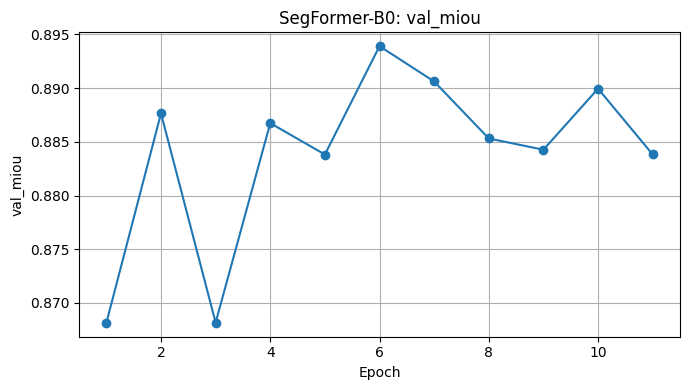

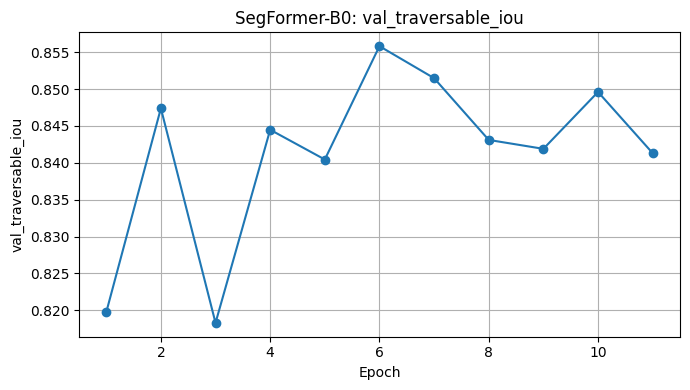

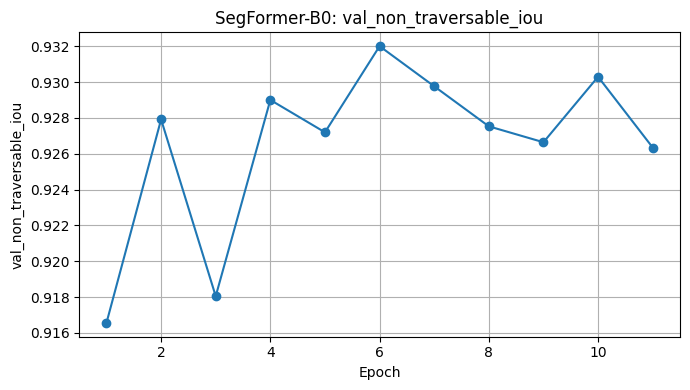

Evaluating SegFormer-B0 ORFD test:   0%|          | 0/320 [00:00<?, ?it/s]

Per-image SegFormer-B0:   0%|          | 0/320 [00:00<?, ?it/s]


Final ORFD test result:


,0
model,SegFormer-B0
source_training_dataset,RUGD
target_training_dataset,ORFD
target_test_dataset,ORFD
source_checkpoint,/content/drive/MyDrive/IRP/02_in_domain_rugd/c...
best_checkpoint,/content/drive/MyDrive/IRP/04_target_domain_fi...
best_epoch,6
best_val_miou,0.89391
baseline_val_miou,0.67298
num_train_images,8398



Fine-tuning ROD


...

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     5    0.020226  0.806997                 0.841057             0.605605  0.723331     0.834016      0.872239 0.00005
No validation improvement. Patience: 4/5

Epoch 6/20


Training:   0%|          | 0/8398 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b0d28cd40e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Evaluating ROD validation:   0%|          | 0/1245 [00:00<?, ?it/s]

 epoch  train_loss  val_loss  val_non_traversable_iou  val_traversable_iou  val_miou  val_mean_f1  val_accuracy      lr
     6    0.019288  0.811407                 0.843158             0.610548  0.726853     0.836546      0.874111 0.00005
No validation improvement. Patience: 5/5
Early stopping.


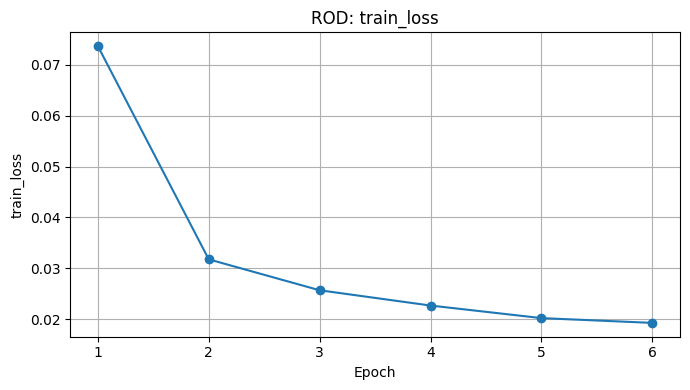

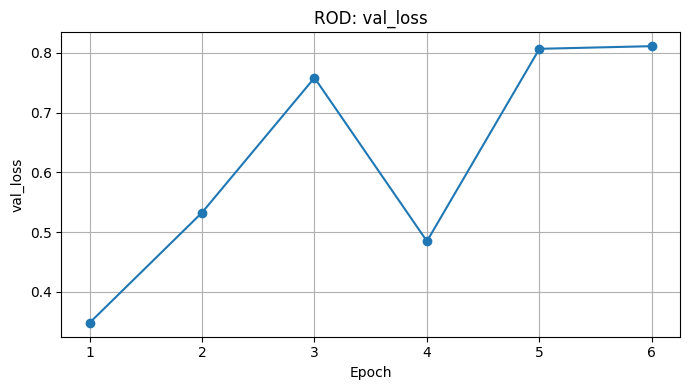

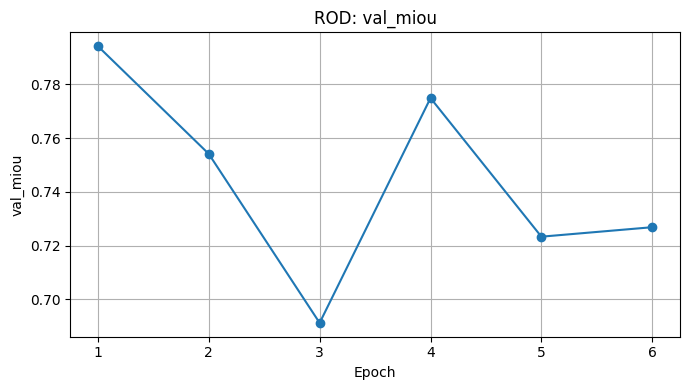

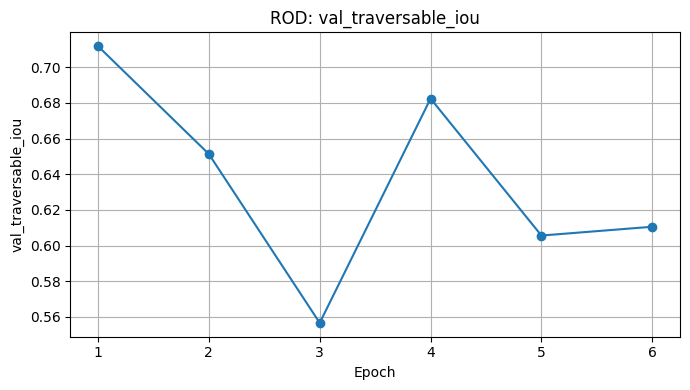

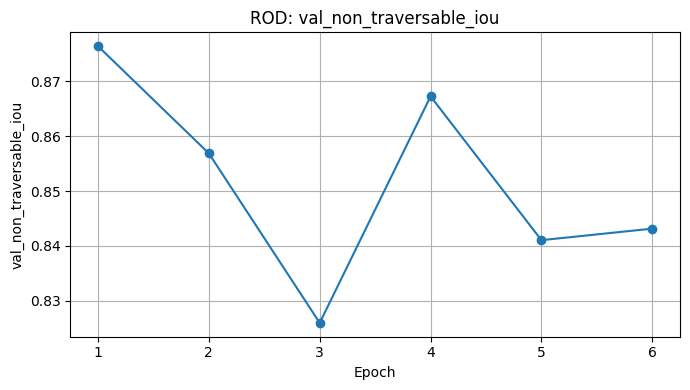

Evaluating ROD ORFD test:   0%|          | 0/2555 [00:00<?, ?it/s]

Per-image ROD:   0%|          | 0/2555 [00:00<?, ?it/s]


Final ORFD test result:


,0
model,ROD
source_training_dataset,RUGD
target_training_dataset,ORFD
target_test_dataset,ORFD
source_checkpoint,/content/drive/MyDrive/IRP/02_in_domain_rugd/c...
best_checkpoint,/content/drive/MyDrive/IRP/04_target_domain_fi...
best_epoch,1
best_val_miou,0.79415
baseline_val_miou,0.564228
num_train_images,8398


,model,num_test_images,non_traversable_iou,traversable_iou,miou,traversable_f1,traversable_precision,traversable_recall,accuracy,mean_inference_time_ms,fps
0,SegFormer-B0,2555,0.968104,0.929127,0.948616,0.963262,0.960039,0.966506,0.977509,7.361528,135.841356
1,U-Net,2555,0.966906,0.926650,0.946778,0.961929,0.957496,0.966403,0.976663,8.126522,123.053878
2,ROD,2555,0.965914,0.924896,0.945405,0.960983,0.953280,0.968811,0.975992,77.554363,12.894181
3,DeepLabV3+,2555,0.961079,0.913671,0.937375,0.954888,0.953465,0.956315,0.972434,4.800611,208.306833


Saved summary: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/orfd_finetune_results.csv


In [18]:
all_results = []

for model_name, checkpoint_path in (
    CHECKPOINTS.items()
):
    result = finetune_model(
        model_name,
        checkpoint_path,
        DEVICE,
    )

    all_results.append(
        result
    )

results_df = pd.DataFrame(
    all_results
)

results_csv = (
    RESULTS_ROOT
    / "orfd_finetune_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False,
)

display_columns = [
    "model",
    "num_test_images",
    "non_traversable_iou",
    "traversable_iou",
    "miou",
    "traversable_f1",
    "traversable_precision",
    "traversable_recall",
    "accuracy",
    "mean_inference_time_ms",
    "fps",
]

display(
    results_df[
        display_columns
    ].sort_values(
        "miou",
        ascending=False,
    ).reset_index(
        drop=True
    )
)

print(
    "Saved summary:",
    results_csv,
)

## 13. Compare zero-shot transfer and ORFD fine-tuning

In [19]:
zero_shot_csv = None

for candidate in (
    ZERO_SHOT_CSV_CANDIDATES
):
    if candidate.exists():
        zero_shot_csv = candidate
        break

if zero_shot_csv is None:
    print(
        "No zero-shot ORFD summary CSV "
        "was found. This comparison is optional."
    )

    for candidate in (
        ZERO_SHOT_CSV_CANDIDATES
    ):
        print(" ", candidate)

else:
    print(
        "Using zero-shot results:",
        zero_shot_csv,
    )

    zero_shot_df = pd.read_csv(
        zero_shot_csv
    )

    fine_tuned_df = pd.read_csv(
        results_csv
    )

    metrics_to_compare = [
        "non_traversable_iou",
        "traversable_iou",
        "miou",
        "traversable_f1",
        "accuracy",
    ]

    zero_indexed = (
        zero_shot_df.set_index(
            "model"
        )
    )

    fine_indexed = (
        fine_tuned_df.set_index(
            "model"
        )
    )

    rows = []

    common_models = sorted(
        set(
            zero_indexed.index
        ).intersection(
            fine_indexed.index
        )
    )

    for model_name in common_models:
        row = {
            "model": model_name,
        }

        for metric in (
            metrics_to_compare
        ):
            if (
                metric
                not in zero_indexed.columns
                or metric
                not in fine_indexed.columns
            ):
                continue

            zero_value = (
                zero_indexed.loc[
                    model_name,
                    metric,
                ]
            )

            fine_value = (
                fine_indexed.loc[
                    model_name,
                    metric,
                ]
            )

            row[
                f"{metric}_zero_shot"
            ] = zero_value

            row[
                f"{metric}_finetuned"
            ] = fine_value

            row[
                f"{metric}_delta"
            ] = (
                fine_value
                - zero_value
            )

        rows.append(row)

    improvement_df = pd.DataFrame(
        rows
    )

    improvement_path = (
        RESULTS_ROOT
        / "zero_shot_vs_orfd_finetuned.csv"
    )

    improvement_df.to_csv(
        improvement_path,
        index=False,
    )

    display(
        improvement_df
    )

    print(
        "Saved comparison:",
        improvement_path,
    )

Using zero-shot results: /content/drive/MyDrive/IRP/03_cross_dataset/rugd_to_orfd/rugd_checkpoints_on_orfd_summary.csv


,model,non_traversable_iou_zero_shot,non_traversable_iou_finetuned,non_traversable_iou_delta,traversable_iou_zero_shot,traversable_iou_finetuned,traversable_iou_delta,miou_zero_shot,miou_finetuned,miou_delta,traversable_f1_zero_shot,traversable_f1_finetuned,traversable_f1_delta,accuracy_zero_shot,accuracy_finetuned,accuracy_delta
0,DeepLabV3+,0.607262,0.961079,0.353817,0.357177,0.913671,0.556494,0.482220,0.937375,0.455155,0.526353,0.954888,0.428535,0.677614,0.972434,0.294821
1,ROD,0.596560,0.965914,0.369354,0.384505,0.924896,0.540391,0.490532,0.945405,0.454872,0.555441,0.960983,0.405542,0.677772,0.975992,0.298220
2,SegFormer-B0,0.561529,0.968104,0.406575,0.456638,0.929127,0.472490,0.509084,0.948616,0.439532,0.626975,0.963262,0.336287,0.679595,0.977509,0.297914
3,U-Net,0.613364,0.966906,0.353542,0.428451,0.926650,0.498200,0.520907,0.946778,0.425871,0.599882,0.961929,0.362047,0.700244,0.976663,0.276419


Saved comparison: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/zero_shot_vs_orfd_finetuned.csv


## 14. Qualitative visualisation of fine-tuned predictions

All four models are supported.

Each figure uses five columns:

`RGB | GT traversable | Prediction | Prediction overlay | Errors`

In [25]:
def load_finetuned_model(
    model_name,
    device,
):
    model_output_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    checkpoint_path = (
        model_output_dir
        / "best_orfd_finetuned.pth"
    )

    checkpoint = load_checkpoint_file(
        checkpoint_path
    )

    model = build_model(
        model_name,
        checkpoint=checkpoint,
    )

    model = load_checkpoint_into_model(
        model,
        checkpoint,
        strict=True,
    )

    return model.to(
        device
    ).eval()


def dataset_for_model(
    model_name,
):
    if model_name == "ROD":
        return rod_test_dataset

    return test_dataset


@torch.inference_mode()
def predict_test_index(
    model_name,
    model,
    index,
):
    dataset = dataset_for_model(
        model_name
    )

    sample = dataset[index]

    image = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
        .float()
    )

    output = model(image)

    # --------------------------------------------------
    # ROD: prediction is in padded 512x512 coordinates
    # --------------------------------------------------
    if model_name == "ROD":
        logits = extract_logits(
            output,
            target_size=INPUT_SIZE,
        )

        padded_prediction = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        # Read ORIGINAL image to recover its aspect ratio.
        original_image = Image.open(
            sample["image_path"]
        ).convert("RGB")

        original_w, original_h = (
            original_image.size
        )

        # Reproduce exactly the padding geometry used by ROD.
        scale = (
            INPUT_SIZE[0]
            / max(
                original_h,
                original_w,
            )
        )

        new_h = int(
            round(
                original_h * scale
            )
        )

        new_w = int(
            round(
                original_w * scale
            )
        )

        top = (
            INPUT_SIZE[0]
            - new_h
        ) // 2

        left = (
            INPUT_SIZE[1]
            - new_w
        ) // 2

        # Remove padding.
        cropped_prediction = (
            padded_prediction[
                top:top + new_h,
                left:left + new_w,
            ]
        )

        # Restore prediction to original image resolution.
        prediction = np.array(
            Image.fromarray(
                cropped_prediction
            ).resize(
                (
                    original_w,
                    original_h,
                ),
                resample=(
                    Image.Resampling.NEAREST
                ),
            ),
            dtype=np.uint8,
        )

    # --------------------------------------------------
    # U-Net / DeepLabV3+ / SegFormer
    # --------------------------------------------------
    else:
        mask_512 = (
            sample["mask"]
            .cpu()
            .numpy()
        )

        logits = extract_logits(
            output,
            target_size=(
                mask_512.shape
            ),
        )

        prediction_512 = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        original_image = Image.open(
            sample["image_path"]
        ).convert("RGB")

        original_w, original_h = (
            original_image.size
        )

        prediction = np.array(
            Image.fromarray(
                prediction_512
            ).resize(
                (
                    original_w,
                    original_h,
                ),
                resample=(
                    Image.Resampling.NEAREST
                ),
            ),
            dtype=np.uint8,
        )

    # --------------------------------------------------
    # Always use ORIGINAL RGB and GT for visualisation
    # --------------------------------------------------
    rgb = np.array(
        Image.open(
            sample["image_path"]
        ).convert("RGB")
    ).astype(
        np.float32
    ) / 255.0

    mask = np.array(
        Image.open(
            sample["mask_path"]
        ).convert("L"),
        dtype=np.uint8,
    )

    return (
        sample,
        rgb,
        mask,
        prediction,
    )


def make_error_map(
    mask,
    prediction,
):
    valid = (
        mask != IGNORE_INDEX
    )

    false_traversable = (
        valid
        & (
            mask
            == NON_TRAVERSABLE_CLASS
        )
        & (
            prediction
            == TRAVERSABLE_CLASS
        )
    )

    false_non_traversable = (
        valid
        & (
            mask
            == TRAVERSABLE_CLASS
        )
        & (
            prediction
            == NON_TRAVERSABLE_CLASS
        )
    )

    error_map = np.zeros(
        (
            mask.shape[0],
            mask.shape[1],
            3,
        ),
        dtype=np.uint8,
    )

    error_map[
        false_traversable
    ] = [255, 0, 0]

    error_map[
        false_non_traversable
    ] = [0, 100, 255]

    return error_map


def show_prediction_case(
    model_name,
    model,
    index,
    title_text=None,
    save_path=None,
):
    (
        sample,
        rgb,
        mask,
        prediction,
    ) = predict_test_index(
        model_name,
        model,
        index,
    )

    error_map = make_error_map(
        mask,
        prediction,
    )

    figure, axes = plt.subplots(
        1,
        5,
        figsize=(23, 5),
    )

    axes[0].imshow(
        rgb
    )
    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        mask
        == TRAVERSABLE_CLASS,
        cmap="gray",
    )
    axes[1].set_title(
        "GT traversable"
    )

    axes[2].imshow(
        prediction
        == TRAVERSABLE_CLASS,
        cmap="gray",
    )
    axes[2].set_title(
        f"{model_name} prediction"
    )

    axes[3].imshow(
        rgb
    )
    axes[3].imshow(
        prediction
        == TRAVERSABLE_CLASS,
        alpha=0.4,
        cmap="Greens",
    )
    axes[3].set_title(
        "Prediction overlay"
    )

    axes[4].imshow(
        error_map
    )
    axes[4].set_title(
        "Errors\n"
        "red=false traversable\n"
        "blue=false non-traversable"
    )

    for axis in axes:
        axis.axis("off")

    plt.suptitle(
        title_text
        if title_text is not None
        else sample["image_path"]
    )

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        figure.savefig(
            save_path,
            dpi=180,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(
        figure
    )


# Optional random examples.
for model_name in MODEL_DISPLAY_ORDER:
    model = load_finetuned_model(
        model_name,
        DEVICE,
    )

    generator = random.Random(
        RANDOM_SEED
    )

    indices = generator.sample(
        range(
            len(
                dataset_for_model(
                    model_name
                )
            )
        ),
        min(
            3,
            len(
                dataset_for_model(
                    model_name
                )
            ),
        ),
    )

    for index in indices:
        show_prediction_case(
            model_name,
            model,
            index,
        )

Output hidden; open in https://colab.research.google.com to view.

## 15. Top-5 and Bottom-5 qualitative cases

For every fine-tuned model, the five highest-mIoU and five lowest-mIoU ORFD test images are:

1. listed in a table;
2. displayed using the same five-column layout;
3. saved under `ranked_cases/`.

In [26]:
RANKED_CASES_ROOT = (
    RESULTS_ROOT
    / "ranked_cases"
)

RANKED_CASES_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


def find_test_index(
    model_name,
    image_path,
):
    dataset = dataset_for_model(
        model_name
    )

    target_path = str(
        Path(
            str(image_path)
        )
    )

    candidate_paths = dataset.df[
        "image_path"
    ].astype(str).map(
        lambda path: str(
            Path(path)
        )
    )

    matches = dataset.df[
        candidate_paths == target_path
    ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one test sample for "
            f"{image_path}, found {len(matches)}."
        )

    return int(
        matches.index[0]
    )

for model_name in MODEL_DISPLAY_ORDER:
    model_output_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    per_image_path = (
        model_output_dir
        / "orfd_test_per_image_metrics.csv"
    )

    dataframe = pd.read_csv(
        per_image_path
    )

    valid_df = dataframe.dropna(
        subset=["miou"]
    )

    top_five = (
        valid_df
        .sort_values(
            "miou",
            ascending=False,
        )
        .head(5)
    )

    bottom_five = (
        valid_df
        .sort_values(
            "miou",
            ascending=True,
        )
        .head(5)
    )

    top_five.to_csv(
        model_output_dir
        / "top5_cases.csv",
        index=False,
    )

    bottom_five.to_csv(
        model_output_dir
        / "bottom5_cases.csv",
        index=False,
    )

    model = load_finetuned_model(
        model_name,
        DEVICE,
    )

    for group_name, selected in [
        ("Top-5 Best", top_five),
        ("Bottom-5 Worst", bottom_five),
    ]:
        print(
            "\n" + "=" * 90
        )

        print(
            f"{model_name}: {group_name}"
        )

        print(
            "=" * 90
        )

        display(
            selected[
                [
                    "sequence",
                    "stem",
                    "non_traversable_iou",
                    "traversable_iou",
                    "miou",
                    "accuracy",
                ]
            ].reset_index(
                drop=True
            )
        )

        for rank, (_, row) in enumerate(
            selected.iterrows(),
            start=1,
        ):
            index = find_test_index(
            model_name,
            row["image_path"],
            )

            safe_group = (
                group_name.lower()
                .replace(" ", "_")
                .replace("-", "")
            )

            save_path = (
                RANKED_CASES_ROOT
                / model_safe_name(
                    model_name
                )
                / safe_group
                / (
                    f"{rank:02d}_"
                    f"{row['stem']}.png"
                )
            )

            show_prediction_case(
                model_name=model_name,
                model=model,
                index=index,
                title_text=(
                    f"{model_name} | "
                    f"{group_name} #{rank} | "
                    f"mIoU={row['miou']:.4f}"
                ),
                save_path=save_path,
            )

Output hidden; open in https://colab.research.google.com to view.

## 16. Common failure cases across all four fine-tuned models

Common failures are ranked by the **average per-image mIoU across all four fine-tuned models**.

The worst five cases are displayed with six columns:

`RGB | Ground Truth | U-Net | DeepLabV3+ | SegFormer-B0 | ROD`

===== Common worst cases =====


,sequence,stem,image_path,mask_path,U-Net,DeepLabV3+,SegFormer-B0,ROD,average_miou
0,y2021_0228_1802,1620330258644,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.848969,0.720277,0.730015,0.669664,0.742231
1,y2021_0228_1802,1620330258850,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.854944,0.762232,0.711988,0.645522,0.743672
2,y2021_0228_1802,1620330257559,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.760246,0.784471,0.796607,0.647651,0.747244
3,y2021_0228_1802,1620330258455,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.851607,0.752271,0.737409,0.659902,0.750297
4,y2021_0228_1802,1620330257737,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.759055,0.764782,0.795249,0.684505,0.750898
5,y2021_0228_1802,1620330258938,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.865177,0.788032,0.715555,0.635640,0.751101
6,y2021_0228_1802,1620330258157,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.819950,0.757531,0.759272,0.684280,0.755258
7,y2021_0228_1802,1620330257256,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.785095,0.808354,0.785919,0.719927,0.774824
8,y2021_0228_1802,1620330259035,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.899246,0.782602,0.765188,0.657274,0.776078
9,y2021_0228_1802,1620330258052,/content/ORFD_RGB/testing/y2021_0228_1802/imag...,/content/ORFD_RGB/testing/y2021_0228_1802/gt_i...,0.795384,0.800935,0.813592,0.696149,0.776515


Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/common_failure_cases/common_failure_01_1620330258644.png


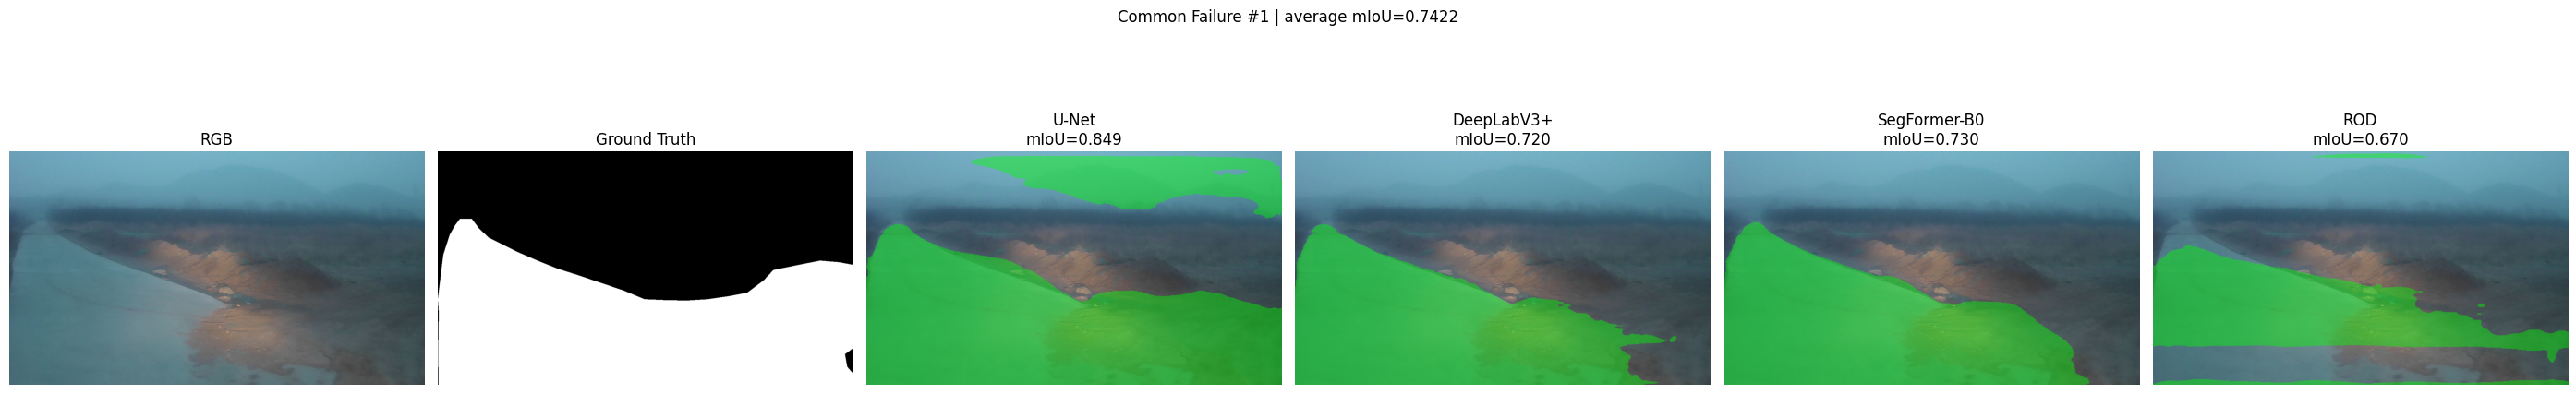

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/common_failure_cases/common_failure_02_1620330258850.png


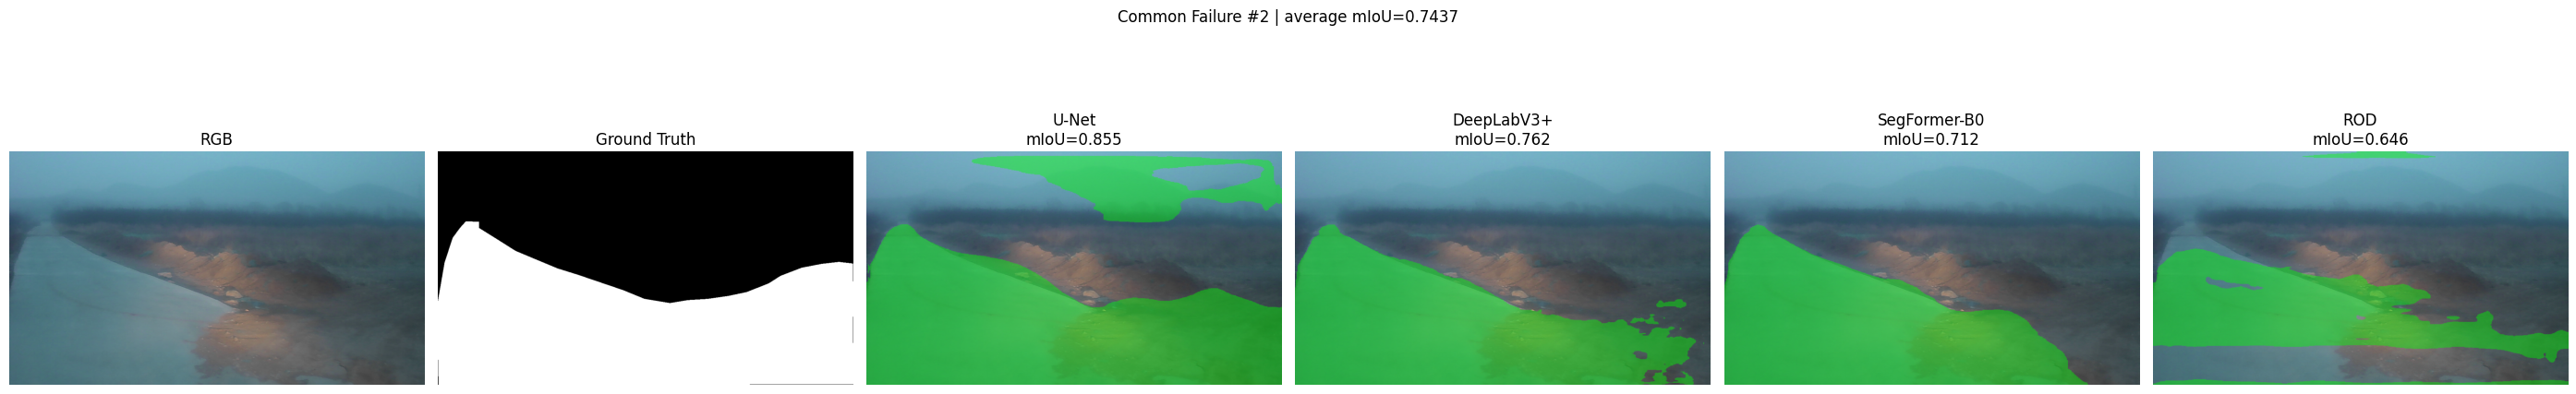

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/common_failure_cases/common_failure_03_1620330257559.png


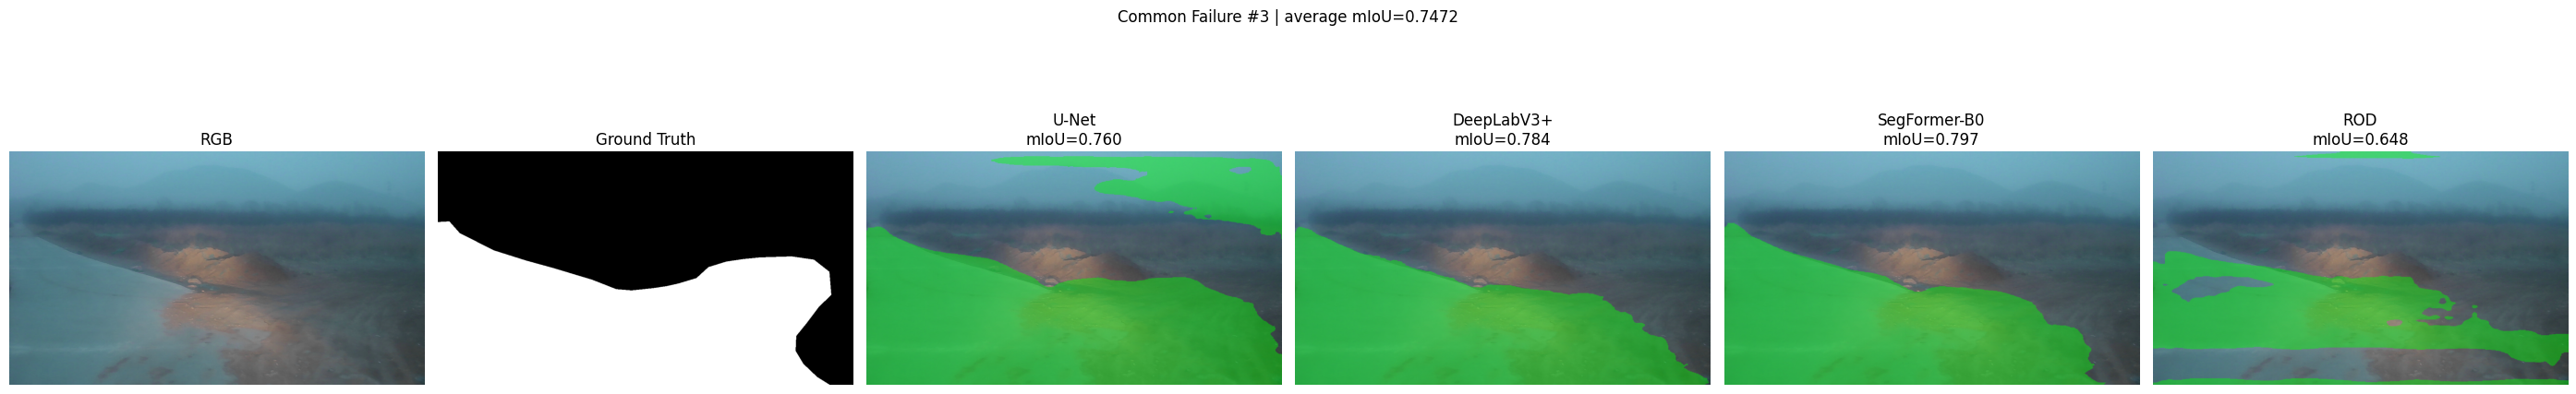

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/common_failure_cases/common_failure_04_1620330258455.png


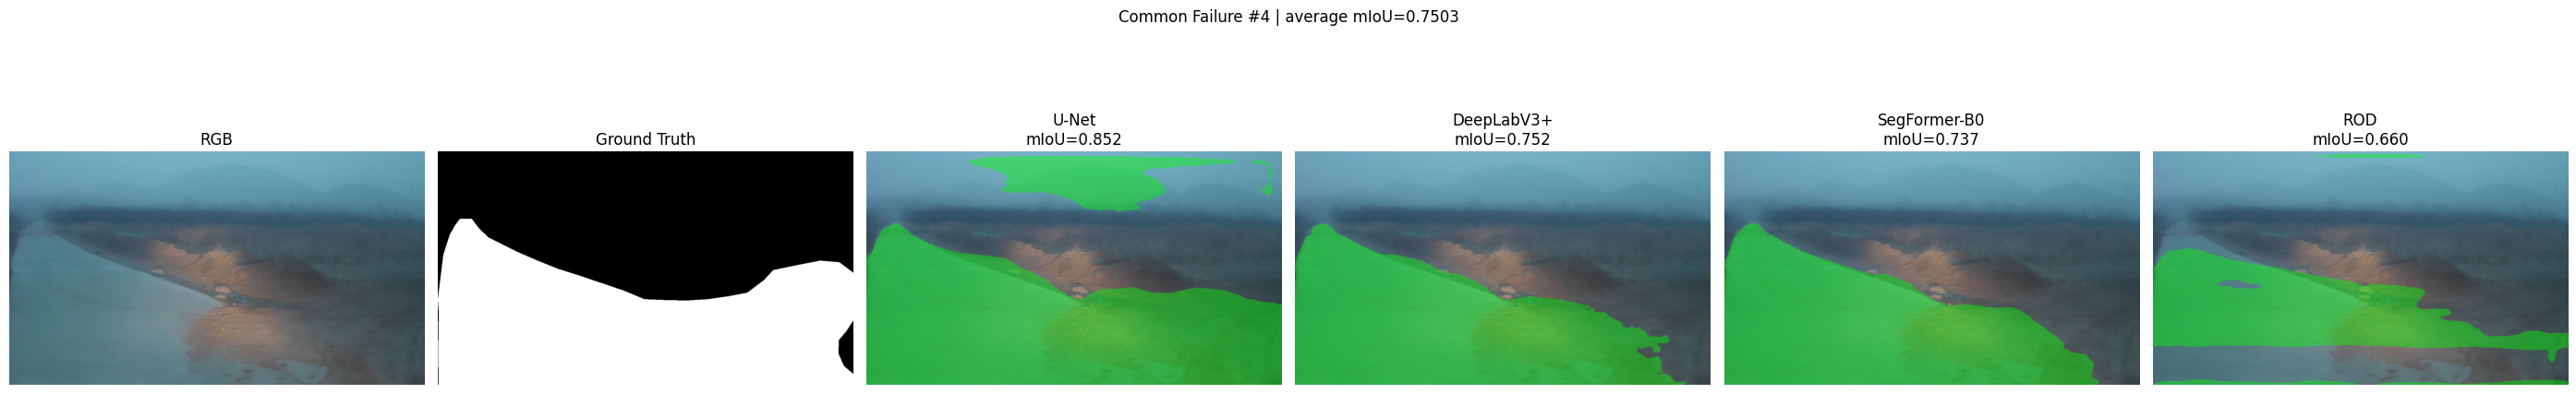

Saved: /content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd/common_failure_cases/common_failure_05_1620330257737.png


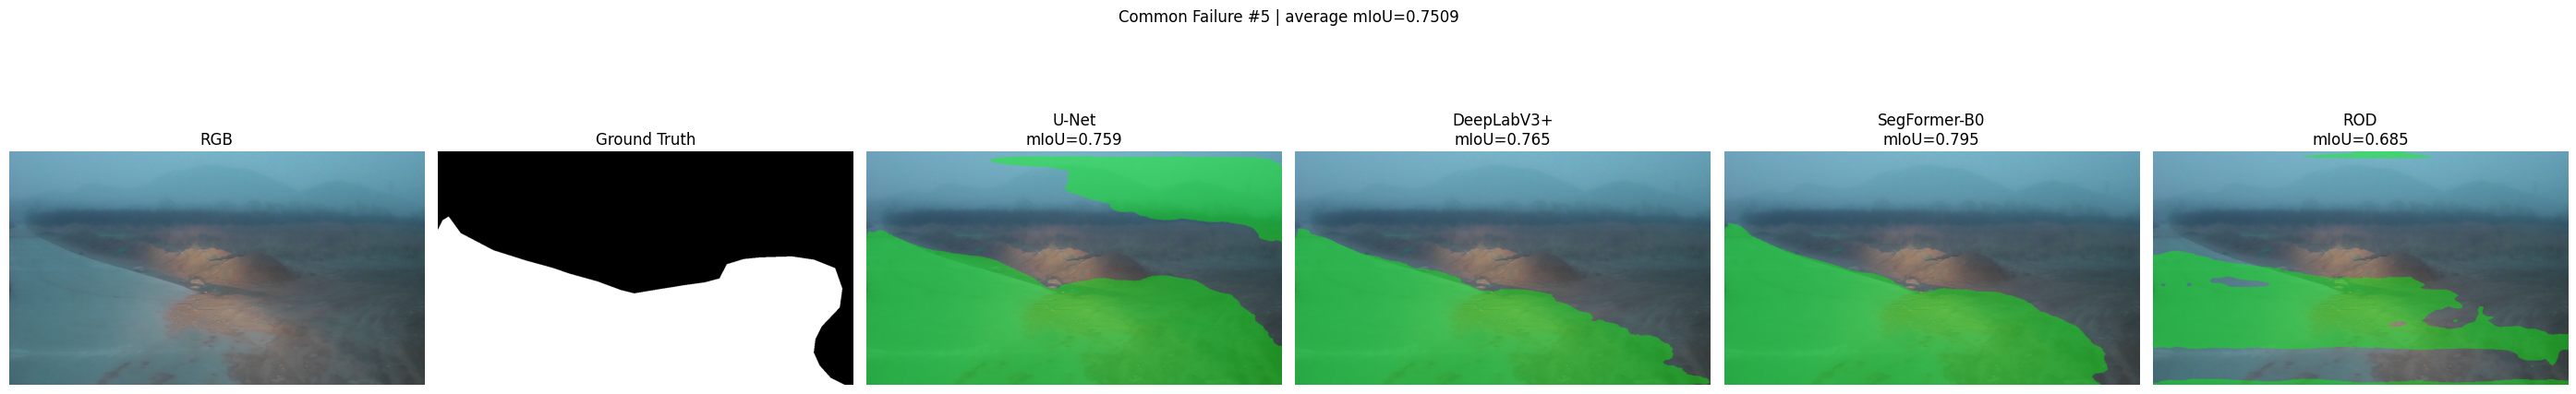


All results are saved directly to:
/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd

No shutil.copytree step is used.


In [27]:
combined = None

for model_name in MODEL_DISPLAY_ORDER:
    model_output_dir = (
        RESULTS_ROOT
        / model_safe_name(
            model_name
        )
    )

    dataframe = pd.read_csv(
        model_output_dir
        / "orfd_test_per_image_metrics.csv"
    )

    subset = dataframe[
        [
            "sequence",
            "stem",
            "image_path",
            "mask_path",
            "miou",
        ]
    ].rename(
        columns={
            "miou": model_name
        }
    )

    if combined is None:
        combined = subset
    else:
        combined = combined.merge(
            subset,
            on=[
                "sequence",
                "stem",
                "image_path",
                "mask_path",
            ],
            how="inner",
        )


combined[
    "average_miou"
] = combined[
    MODEL_DISPLAY_ORDER
].mean(
    axis=1,
    skipna=False,
)


common_worst_10 = (
    combined
    .dropna(
        subset=[
            "average_miou"
        ]
    )
    .sort_values(
        "average_miou",
        ascending=True,
    )
    .head(10)
    .reset_index(
        drop=True
    )
)

common_worst_5 = (
    common_worst_10
    .head(5)
    .copy()
)

common_worst_10.to_csv(
    RESULTS_ROOT
    / "common_worst_finetuned_orfd_cases.csv",
    index=False,
)

print(
    "===== Common worst cases ====="
)

display(
    common_worst_10
)


def original_orfd_rgb(
    image_path,
):
    return np.array(
        Image.open(
            image_path
        ).convert("RGB")
    )


def original_orfd_gt(
    mask_path,
):
    return load_orfd_binary_mask(
        mask_path
    ).astype(
        np.uint8
    )


def predict_original_resolution(
    model_name,
    model,
    image_path,
):
    image = Image.open(
        image_path
    ).convert("RGB")

    original_w, original_h = (
        image.size
    )

    if model_name == "ROD":
        image_np = np.array(
            image,
            dtype=np.uint8,
        )

        dummy_mask = np.zeros(
            image_np.shape[:2],
            dtype=np.uint8,
        )

        padded_image, _ = (
            rod_resize_pad_pair(
                image_np,
                dummy_mask,
                size=INPUT_SIZE[0],
            )
        )

        padded_image = (
            padded_image.astype(
                np.float32
            )
            - ROD_PIXEL_MEAN
        ) / ROD_PIXEL_STD

        tensor = (
            torch.from_numpy(
                padded_image
            )
            .permute(
                2, 0, 1
            )
            .unsqueeze(0)
            .to(DEVICE)
            .float()
        )

    else:
        resized = TF.resize(
            image,
            INPUT_SIZE,
            interpolation=(
                InterpolationMode.BILINEAR
            ),
            antialias=True,
        )

        tensor = TF.to_tensor(
            resized
        )

        tensor = TF.normalize(
            tensor,
            IMAGENET_MEAN,
            IMAGENET_STD,
        )

        tensor = (
            tensor
            .unsqueeze(0)
            .to(DEVICE)
        )

    with torch.inference_mode():
        logits = extract_logits(
            model(tensor),
            target_size=INPUT_SIZE,
        )

        prediction = (
            torch.argmax(
                logits,
                dim=1,
            )[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

    prediction = np.array(
        Image.fromarray(
            prediction
        ).resize(
            (
                original_w,
                original_h,
            ),
            resample=(
                Image.Resampling.NEAREST
            ),
        ),
        dtype=np.uint8,
    )

    return prediction


def traversable_overlay(
    rgb_uint8,
    prediction,
    alpha=0.42,
):
    rgb = (
        rgb_uint8.astype(
            np.float32
        )
        / 255.0
    )

    overlay = rgb.copy()

    region = (
        prediction
        == TRAVERSABLE_CLASS
    )

    green = np.zeros_like(
        rgb
    )

    green[..., 1] = 1.0

    overlay[
        region
    ] = (
        (1.0 - alpha)
        * rgb[
            region
        ]
        + alpha
        * green[
            region
        ]
    )

    return np.clip(
        overlay,
        0,
        1,
    )


COMMON_FAILURE_DIR = (
    RESULTS_ROOT
    / "common_failure_cases"
)

COMMON_FAILURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


fine_tuned_models = {
    model_name: load_finetuned_model(
        model_name,
        DEVICE,
    )
    for model_name
    in MODEL_DISPLAY_ORDER
}


for rank, (_, row) in enumerate(
    common_worst_5.iterrows(),
    start=1,
):
    rgb = original_orfd_rgb(
        row["image_path"]
    )

    gt = original_orfd_gt(
        row["mask_path"]
    )

    figure, axes = plt.subplots(
        1,
        6,
        figsize=(28, 5),
    )

    axes[0].imshow(
        rgb
    )
    axes[0].set_title(
        "RGB"
    )

    axes[1].imshow(
        gt
        == TRAVERSABLE_CLASS,
        cmap="gray",
    )
    axes[1].set_title(
        "Ground Truth"
    )

    for column, model_name in enumerate(
        MODEL_DISPLAY_ORDER,
        start=2,
    ):
        prediction = (
            predict_original_resolution(
                model_name,
                fine_tuned_models[
                    model_name
                ],
                row["image_path"],
            )
        )

        overlay = (
            traversable_overlay(
                rgb,
                prediction,
            )
        )

        axes[column].imshow(
            overlay
        )

        axes[column].set_title(
            f"{model_name}\n"
            f"mIoU={row[model_name]:.3f}"
        )

    for axis in axes:
        axis.axis(
            "off"
        )

    figure.suptitle(
        f"Common Failure #{rank} | "
        f"average mIoU="
        f"{row['average_miou']:.4f}"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.90,
        ]
    )

    save_path = (
        COMMON_FAILURE_DIR
        / (
            f"common_failure_"
            f"{rank:02d}_"
            f"{row['stem']}.png"
        )
    )

    figure.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight",
    )

    print(
        "Saved:",
        save_path,
    )

    plt.show()

    plt.close(
        figure
    )


print(
    "\nAll results are saved directly to:"
)

print(
    RESULTS_ROOT
)

print(
    "\nNo shutil.copytree step is used."
)

## Reporting statement

The final ORFD target-domain adaptation experiment evaluates four RUGD-pretrained models:

- U-Net
- DeepLabV3+
- SegFormer-B0
- ROD

Each model is fine-tuned on the ORFD training split, selected by validation mIoU, and evaluated on the held-out ORFD test split.

The final qualitative analysis includes:
- per-model Top-5 cases;
- per-model Bottom-5 cases;
- common failure cases shared across all four fine-tuned models.

All results are saved directly under:

`/content/drive/MyDrive/IRP/04_target_domain_finetuning/orfd`